# Project I ArtBench-10
**Student:** Filipe de Castro Oliveira 2024131032


---
## Setup

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted (Colab).')
except ModuleNotFoundError:
    print('Ambiente local detectado: sem google.colab.')
    print('Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.')

Ambiente local detectado: sem google.colab.
Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.


In [2]:
from __future__ import annotations

import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths (Colab or local + Google Drive Desktop)
WORKSPACE_ROOT = Path.cwd()

def _is_usable_dir(p: Path) -> bool:
    try:
        return p.exists() and p.is_dir()
    except OSError:
        return False

if "google.colab" in sys.modules:
    PROJECT_ROOT = Path('/content/drive/MyDrive/MIACD - GAI')
else:
    # Opcional: setar no terminal -> $env:GOOGLE_DRIVE_ROOT='G:/My Drive/MIACD - GAI'
    _env_drive_root = os.environ.get('GOOGLE_DRIVE_ROOT', '').strip()
    _candidates = []
    if _env_drive_root:
        _candidates.append(Path(_env_drive_root).expanduser())
    _candidates += [
        Path('G:/My Drive/MIACD - GAI'),
        Path.home() / 'My Drive' / 'MIACD - GAI',
        Path.home() / 'Google Drive' / 'My Drive' / 'MIACD - GAI',
        WORKSPACE_ROOT / 'drive_outputs',
    ]
    PROJECT_ROOT = next((p for p in _candidates if _is_usable_dir(p)), _candidates[-1])

# Prefer scripts from workspace; fallback to drive root
SCRIPTS_DIR = WORKSPACE_ROOT / 'scripts'
if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    SCRIPTS_DIR = PROJECT_ROOT / 'scripts'

EXPORT_ROOT = PROJECT_ROOT / 'exported_data'
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

RUNS_DIR = WORKSPACE_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        f"Could not resolve scripts folder. Tried: {WORKSPACE_ROOT / 'scripts'} and {PROJECT_ROOT / 'scripts'}"
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('WORKSPACE_ROOT =', WORKSPACE_ROOT)
print('PROJECT_ROOT   =', PROJECT_ROOT)
print('SCRIPTS_DIR    =', SCRIPTS_DIR)
print('EXPORT_ROOT    =', EXPORT_ROOT)
print('RUNS_DIR       =', RUNS_DIR)

WORKSPACE_ROOT = c:\Users\User\source\repos\genai-project1
PROJECT_ROOT   = c:\Users\User\source\repos\genai-project1\drive_outputs
SCRIPTS_DIR    = c:\Users\User\source\repos\genai-project1\scripts
EXPORT_ROOT    = c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data
RUNS_DIR       = c:\Users\User\source\repos\genai-project1\runs


In [4]:
import kagglehub
import os

def _is_artbench_root(p: Path) -> bool:
    p = Path(p)
    return (p / 'ArtBench-10.csv').exists() and (p / 'artbench-10-python').exists()

# 1) Try to reuse existing local dataset first
candidate_roots = []

if 'KAGGLE_ROOT' in globals() and KAGGLE_ROOT is not None:
    candidate_roots.append(Path(KAGGLE_ROOT))

if 'PROJECT_ROOT' in globals():
    candidate_roots += [
        Path(PROJECT_ROOT),
        Path(PROJECT_ROOT) / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'datasets' / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'data' / 'ArtBench-10',
    ]

if 'WORKSPACE_ROOT' in globals():
    candidate_roots += [
        Path(WORKSPACE_ROOT),
        Path(WORKSPACE_ROOT) / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'datasets' / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'data' / 'ArtBench-10',
    ]

KAGGLE_ROOT = next((p for p in candidate_roots if _is_artbench_root(p)), None)

if KAGGLE_ROOT is not None:
    print(f"Dataset já existe localmente. Pulando download.")
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")
else:
    # 2) Fallback: download using kagglehub
    print("Downloading ArtBench-10 dataset using kagglehub...")
    download_base_path = kagglehub.dataset_download("alexanderliao/artbench10")
    print(f"Dataset downloaded to: {download_base_path}")

    found_root = None
    for root, dirs, files in os.walk(download_base_path):
        if 'ArtBench-10.csv' in files and 'artbench-10-python' in dirs:
            found_root = Path(root)
            break

    if found_root is None:
        raise FileNotFoundError(
            "Could not find the 'ArtBench-10' root directory within the downloaded KaggleHub dataset."
        )

    KAGGLE_ROOT = found_root
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")

# This cell now reuses local data when available; otherwise it downloads.

c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2
Set KAGGLE_ROOT to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]
test_hf  = hf_ds["test"]

print("Train size:", len(train_hf))
print("Test size :", len(test_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2'
Train size: 50000
Test size : 10000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [6]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [7]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

train_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

val_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

transform = train_transform  # backward-compat alias


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=train_transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Visualize a sample grid

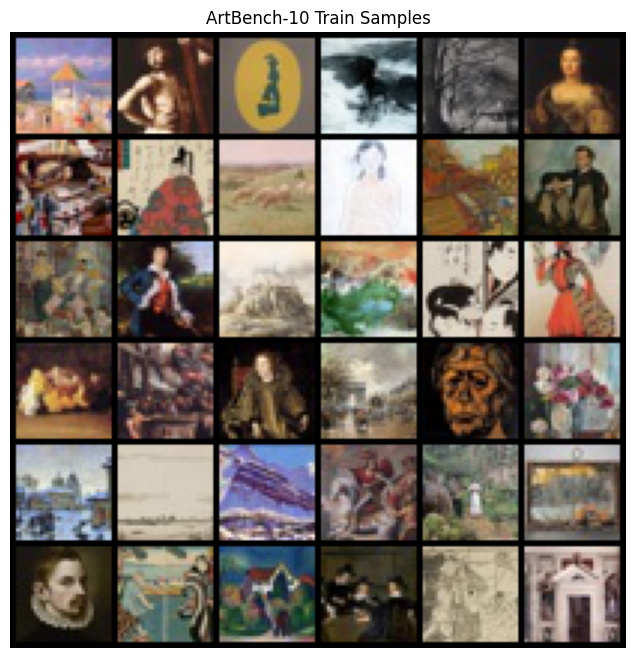

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [8]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

---
# Evaluation Setup

FID / KID evaluation functions and shared configuration.

In [9]:
"""
Evaluation: FID and KID computation.
Requires: pip install torchmetrics[image]
"""

import numpy as np
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance


def generate_samples(model, model_type, num_samples, latent_dim, img_channels, img_size, device, num_inference_steps=None):
    """Generate samples. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    model.eval()
    model.to(device)
    results = []
    batch_size = 64
    with torch.no_grad():
        generated = 0
        while generated < num_samples:
            n = min(batch_size, num_samples - generated)
            if model_type == "vae":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model.decode(z)
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "gan":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model(z)
                imgs = (imgs + 1.0) / 2.0
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "diffusion":
                imgs = model.sample(
                    num_samples=n,
                    shape=(img_channels, img_size, img_size),
                    device=device,
                    num_inference_steps=num_inference_steps,
                )
                imgs = torch.clamp(imgs, 0.0, 1.0)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")
            results.append((imgs * 255).byte().cpu())
            generated += n
    return torch.cat(results, dim=0)[:num_samples]


def get_real_samples(dataset, num_samples, seed):
    """Sample real images from dataset. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    rng = torch.Generator()
    rng.manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=rng)[:num_samples].tolist()
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=128, shuffle=False, num_workers=0)
    imgs_list = []
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        imgs_list.append((imgs * 255).byte())
    return torch.cat(imgs_list, dim=0)[:num_samples]


def compute_fid_kid_single(fake_imgs_uint8, real_imgs_uint8, kid_subset_size, device):
    """Compute FID and KID. Returns (fid, kid_mean, kid_std)."""
    bs = 128
    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        fid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        fid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    fid_val = fid_metric.compute().item()
    del fid_metric

    kid_metric = KernelInceptionDistance(subset_size=kid_subset_size, subsets=50, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        kid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        kid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    kid_mean, kid_std = kid_metric.compute()
    del kid_metric

    return fid_val, kid_mean.item(), kid_std.item()


def evaluate_model(
    model,
    real_dataset,
    model_type,
    latent_dim=128,
    img_channels=3,
    img_size=32,
    num_generated=5000,
    num_real=5000,
    kid_subset_size=100,
    n_repetitions=10,
    base_seed=0,
    device="cuda",
    num_inference_steps=None,
):
    """Full evaluation: n_repetitions with different seeds. Reports mean±std of FID and KID."""
    fid_list, kid_mean_list = [], []
    for rep in range(n_repetitions):
        seed = base_seed + rep * 137
        torch.manual_seed(seed)
        np.random.seed(seed)
        fake_imgs = generate_samples(model, model_type, num_generated, latent_dim, img_channels, img_size, device, num_inference_steps)
        real_imgs = get_real_samples(real_dataset, num_real, seed)
        fid, kid_m, kid_s = compute_fid_kid_single(fake_imgs, real_imgs, kid_subset_size, device)
        fid_list.append(fid)
        kid_mean_list.append(kid_m)
        print(f"  [{model_type}] Rep {rep+1}/{n_repetitions} seed={seed} | FID={fid:.2f} | KID={kid_m*1000:.4f}±{kid_s*1000:.4f} (×10⁻³)")

    results = {
        "model_type": model_type,
        "fid_mean": float(np.mean(fid_list)),
        "fid_std": float(np.std(fid_list)),
        "kid_mean": float(np.mean(kid_mean_list)),
        "kid_std": float(np.std(kid_mean_list)),
        "n_repetitions": n_repetitions,
        "num_generated": num_generated,
        "num_real": num_real,
    }
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} | FID: {results['fid_mean']:.2f} ± {results['fid_std']:.2f} | KID: {results['kid_mean']*1000:.4f} ± {results['kid_std']*1000:.4f} (×10⁻³)")
    print(f"{'='*60}\n")
    return results


print("Evaluation functions loaded.")


Evaluation functions loaded.


In [10]:
# ── FID/KID evaluation — shared config & helpers ─────────────────
import csv as _csv
import json as _json
from pathlib import Path

EVAL_NUM_GENERATED = 5000
EVAL_NUM_REAL      = 5000
EVAL_KID_SUBSET    = 100
EVAL_N_REPS        = 10
EVAL_BASE_SEED     = 0
EVAL_DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_runs        = RUNS_DIR if "RUNS_DIR" in globals() else Path("runs")
_results_out = _runs / "evaluation_results.json"


def _best_row(csv_path, key_col, lower_is_better=True):
    if not Path(csv_path).exists():
        return None
    rows = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in _csv.DictReader(f):
            if row.get("status") == "ok":
                try:
                    rows.append((float(row[key_col]), row))
                except (ValueError, KeyError):
                    pass
    if not rows:
        return None
    rows.sort(key=lambda x: x[0], reverse=not lower_is_better)
    return rows[0][1]


def _load_results():
    if _results_out.exists():
        with open(_results_out) as f:
            return _json.load(f)
    return {}


def _save_results(d):
    _runs.mkdir(parents=True, exist_ok=True)
    with open(_results_out, "w") as f:
        _json.dump(d, f, indent=2)
    print(f"Saved → {_results_out}")


def _print_results(d):
    if not d:
        print("No results yet.")
        return
    print(f"\n{'Model':<12} {'FID':>10} {'FID±':>8} {'KID×10³':>12} {'KID±×10³':>12}")
    print("-" * 56)
    for name, res in d.items():
        print(
            f"{name.upper():<12} "
            f"{res['fid_mean']:>10.2f} "
            f"{res['fid_std']:>8.2f} "
            f"{res['kid_mean']*1000:>12.4f} "
            f"{res['kid_std']*1000:>12.4f}"
        )

print("FID/KID config ready. Run each model cell independently.")
print(f"Results file: {_results_out}")
if _results_out.exists():
    _print_results(_load_results())


FID/KID config ready. Run each model cell independently.
Results file: c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--------------------------------------------------------
VAE              195.70     1.00     185.9775       1.3450
DCGAN_FULL       202.48     0.69      91.7944       1.1543
DDPM_FULL         69.46     0.87      47.8215       1.1552
DDIM_FULL         45.01     0.48      24.9569       1.1207


---
## Full 50k Training Set

`train_loader_full` — normalized [-1,1] for DCGAN / DDPM / DDIM.  
`train_loader` (from setup) — unnormalized [0,1] for VAE.  
`test_ds` — test split for FID/KID evaluation.

In [11]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Full 50k loader — normalized [-1,1] — used by DCGAN, DDPM, DDIM
_transform_full = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]
])

train_ds_full = HFDatasetTorch(train_hf, transform=_transform_full, indices=None)
train_loader_full = DataLoader(
    train_ds_full,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# Test dataset — unnormalized [0,1] — used by FID/KID evaluation
_transform_eval = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
])
test_ds = HFDatasetTorch(test_hf, transform=_transform_eval, indices=None)

print(f"Full train dataset : {len(train_ds_full):,} images")
print(f"Test dataset       : {len(test_ds):,} images")
print(f"Batches per epoch  : {len(train_loader_full)}")


Full train dataset : 50,000 images
Test dataset       : 10,000 images
Batches per epoch  : 782


---
## VAE

In [12]:
class Encoder(nn.Module):
    """Encoder maps images to latent space parameters (mu, log_var)."""

    def __init__(
        self,
        img_channels: int = 3,
        latent_dim: int = 128,
        hidden_dims: list = None,
        image_size: int = 32,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        self.hidden_dims = list(hidden_dims)
        self.image_size = int(image_size)
        self.latent_dim = latent_dim

        # Build encoder CNN
        modules = []
        in_channels = img_channels

        for h_dim in self.hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )
            in_channels = h_dim

        self.encoder_cnn = nn.Sequential(*modules)

        # Calculate final feature map size
        # For each stride-2 layer: size = size // 2
        self.feature_map_hw = self.image_size // (2 ** len(self.hidden_dims))

        if self.feature_map_hw < 1:
            raise ValueError(
                f"image_size={self.image_size} too small for "
                f"{len(self.hidden_dims)} downsampling layers"
            )

        final_feature_map_size = self.hidden_dims[-1] * self.feature_map_hw**2

        # Latent parameters
        self.fc_mu = nn.Linear(final_feature_map_size, latent_dim)
        self.fc_log_var = nn.Linear(final_feature_map_size, latent_dim)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Encode image to latent parameters.

        Args:
            x: Input tensor (B, C, H, W)

        Returns:
            mu: Mean of latent distribution (B, latent_dim)
            log_var: Log variance of latent distribution (B, latent_dim)
        """
        x = self.encoder_cnn(x)
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var


In [13]:
class Decoder(nn.Module):
    """Decoder reconstructs images from latent vectors."""

    def __init__(
        self,
        img_channels: int = 3,
        latent_dim: int = 128,
        hidden_dims: list = None,
        image_size: int = 32,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        self.hidden_dims = list(hidden_dims)
        self.image_size = int(image_size)
        self.latent_dim = latent_dim

        # Calculate initial feature map size (same as encoder output)
        self.feature_map_hw = self.image_size // (2 ** len(self.hidden_dims))

        if self.feature_map_hw < 1:
            raise ValueError(
                f"image_size={self.image_size} too small for "
                f"{len(self.hidden_dims)} upsampling layers"
            )

        self.init_channels = self.hidden_dims[-1]

        # Project latent vector to initial feature map
        init_feature_size = self.init_channels * self.feature_map_hw**2
        self.decoder_input = nn.Linear(latent_dim, init_feature_size)

        # Build decoder CNN (reverse order of hidden dims)
        modules = []
        rev_hidden_dims = self.hidden_dims[::-1]

        # Transposed conv layers
        for i in range(len(rev_hidden_dims) - 1):
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        rev_hidden_dims[i],
                        rev_hidden_dims[i + 1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=1,
                    ),
                    nn.BatchNorm2d(rev_hidden_dims[i + 1]),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )

        # Final layer to output channels
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(
                    rev_hidden_dims[-1],
                    img_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.Sigmoid(),  # Output in [0, 1] range
            )
        )

        self.decoder_cnn = nn.Sequential(*modules)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Decode latent vector to image.

        Args:
            z: Latent tensor (B, latent_dim)

        Returns:
            reconstruction: Reconstructed image (B, C, H, W)
        """
        x = self.decoder_input(z)
        x = x.view(-1, self.init_channels, self.feature_map_hw, self.feature_map_hw)
        x = self.decoder_cnn(x)
        return x


In [14]:
class VAE(nn.Module):
    """Variational Autoencoder combining Encoder and Decoder."""

    def __init__(
        self,
        img_channels: int = 3,
        latent_dim: int = 128,
        hidden_dims: list = None,
        image_size: int = 32,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        self.latent_dim = latent_dim

        self.encoder = Encoder(
            img_channels=img_channels,
            latent_dim=latent_dim,
            hidden_dims=hidden_dims,
            image_size=image_size,
        )

        self.decoder = Decoder(
            img_channels=img_channels,
            latent_dim=latent_dim,
            hidden_dims=hidden_dims,
            image_size=image_size,
        )

    def reparameterize(
        self, mu: torch.Tensor, log_var: torch.Tensor
    ) -> torch.Tensor:
        """
        Sample latent vector using reparameterization trick.

        Args:
            mu: Mean of latent distribution (B, latent_dim)
            log_var: Log variance of latent distribution (B, latent_dim)

        Returns:
            z: Sampled latent vector (B, latent_dim)
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std, device=mu.device)
        z = mu + eps * std
        return z

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Full VAE forward pass.

        Args:
            x: Input image (B, C, H, W)

        Returns:
            reconstruction: Reconstructed image (B, C, H, W)
            mu: Latent mean (B, latent_dim)
            log_var: Latent log variance (B, latent_dim)
        """
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decoder(z)
        return reconstruction, mu, log_var

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Encode image to latent parameters."""
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode latent vector to image."""
        return self.decoder(z)

    def sample(self, num_samples: int, device: str = "cpu") -> torch.Tensor:
        """Generate samples from standard normal distribution."""
        z = torch.randn(num_samples, self.latent_dim, device=device)
        return self.decoder(z)


In [15]:
def vae_loss(
    reconstruction: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    log_var: torch.Tensor,
    beta: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Compute VAE loss = reconstruction loss + beta * KL divergence.

    Args:
        reconstruction: Reconstructed image (B, C, H, W) in [0,1]
        x: Original image (B, C, H, W) in [0,1]
        mu: Latent mean (B, latent_dim)
        log_var: Latent log variance (B, latent_dim)
        beta: Weight for KL divergence term

    Returns:
        loss: Total VAE loss
        recon_loss: Reconstruction loss (BCE)
        kl_loss: KL divergence loss
    """
    # Reconstruction loss (Binary Cross-Entropy for [0,1] normalized images)
    recon_loss = F.binary_cross_entropy(reconstruction, x, reduction="mean")

    # KL divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    # Averaged over batch dimension
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

    # Total loss
    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss


def compute_beta_warmup(epoch: int, warmup_epochs: int, beta_max: float) -> float:
    """
    Compute KL divergence weight during warmup phase.

    Linearly increases from 0 to beta_max over warmup_epochs.

    Args:
        epoch: Current epoch (0-indexed)
        warmup_epochs: Number of warmup epochs
        beta_max: Maximum beta value

    Returns:
        beta: Current beta value
    """
    if epoch < warmup_epochs:
        return (epoch / warmup_epochs) * beta_max
    return beta_max

In [ ]:
_m = VAE(img_channels=3, latent_dim=256,
         hidden_dims=[32, 64, 128, 256], image_size=32)
print(_m)
print(f"\nTotal params: {sum(p.numel() for p in _m.parameters()):,}")
del _m

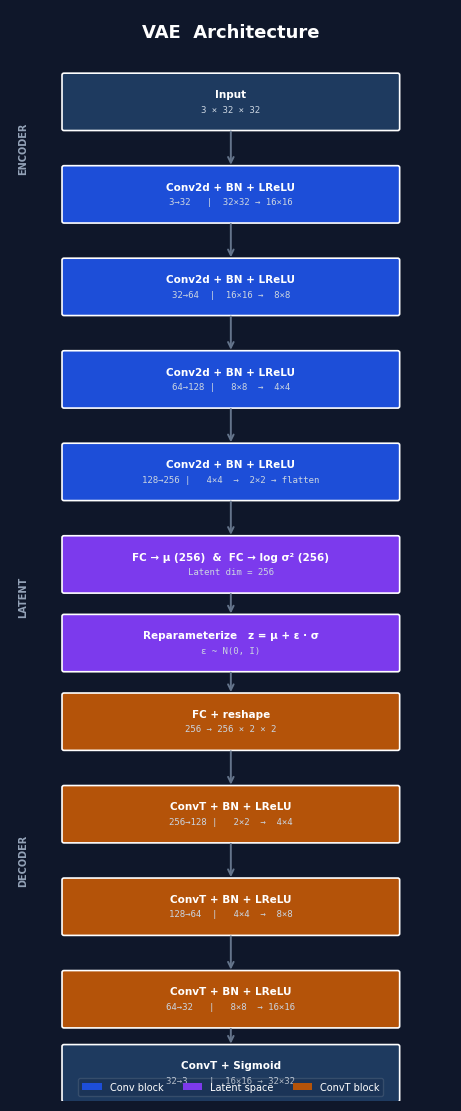

Saved: runs/figures/arch_vae.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

BG      = "#0F172A"
ENCODER = "#1D4ED8"   # blue
LATENT  = "#7C3AED"   # purple
DECODER = "#B45309"   # amber
IO      = "#1E3A5F"   # dark blue
ARROW   = "#64748B"

def _box(ax, cx, cy, w, h, label, sub, color):
    p = FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                       boxstyle="round,pad=0.02",
                       fc=color, ec="white", lw=1.2, zorder=3)
    ax.add_patch(p)
    dy = h*0.14 if sub else 0
    ax.text(cx, cy+dy, label, ha="center", va="center",
            fontsize=7.5, fontweight="bold", color="white", zorder=4)
    if sub:
        ax.text(cx, cy-dy, sub, ha="center", va="center",
                fontsize=6.5, color="#CBD5E1", zorder=4, family="monospace")

def _arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color=ARROW, lw=1.4,
                                mutation_scale=10), zorder=5)

fig, ax = plt.subplots(figsize=(4.5, 11))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 4.5); ax.set_ylim(-0.4, 11.4)
ax.axis("off")

ax.text(2.25, 11.1, "VAE  Architecture", ha="center", fontsize=13,
        fontweight="bold", color="white")

W, H = 3.4, 0.58

layers = [
    (10.4, "Input",                "3 × 32 × 32",           IO),
    (9.4,  "Conv2d + BN + LReLU", "3→32   |  32×32 → 16×16", ENCODER),
    (8.4,  "Conv2d + BN + LReLU", "32→64  |  16×16 →  8×8",  ENCODER),
    (7.4,  "Conv2d + BN + LReLU", "64→128 |   8×8  →  4×4",  ENCODER),
    (6.4,  "Conv2d + BN + LReLU", "128→256 |   4×4  →  2×2 → flatten", ENCODER),
    (5.4,  "FC → μ (256)  &  FC → log σ² (256)", "Latent dim = 256", LATENT),
    (4.55, "Reparameterize   z = μ + ε · σ",     "ε ~ N(0, I)",      LATENT),
    (3.7,  "FC + reshape",        "256 → 256 × 2 × 2",      DECODER),
    (2.7,  "ConvT + BN + LReLU", "256→128 |   2×2  →  4×4",  DECODER),
    (1.7,  "ConvT + BN + LReLU", "128→64  |   4×4  →  8×8",  DECODER),
    (0.7,  "ConvT + BN + LReLU", "64→32   |   8×8  → 16×16", DECODER),
    (-0.1, "ConvT + Sigmoid",    "32→3    |  16×16 → 32×32", IO),
]

for (y, label, sub, color) in layers:
    _box(ax, 2.25, y, W, H, label, sub, color)

for i in range(len(layers)-1):
    y_top = layers[i][0] - H/2
    y_bot = layers[i+1][0] + H/2
    _arrow(ax, 2.25, y_top, 2.25, y_bot)

# Section labels
for y, txt in [(9.9, "ENCODER"), (5.05, "LATENT"), (2.2, "DECODER")]:
    ax.text(0.08, y, txt, fontsize=7, fontweight="bold", color="#94A3B8",
            va="center", rotation=90)

# Legend
handles = [mpatches.Patch(fc=ENCODER, label="Conv block"),
           mpatches.Patch(fc=LATENT,  label="Latent space"),
           mpatches.Patch(fc=DECODER, label="ConvT block")]
ax.legend(handles=handles, loc="lower center", ncol=3, framealpha=0.15,
          labelcolor="white", fontsize=7, facecolor=BG)

plt.tight_layout(pad=0.3)
plt.savefig("runs/figures/arch_vae.png", dpi=180, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Saved: runs/figures/arch_vae.png")


## Train VAE (Full 50k)

Device: cuda
Train size: 50000
Batch size: 64

Starting run: vae_ldim256_ep100_seed42
Run dir: c:\Users\User\source\repos\genai-project1\runs\vae_ldim256_ep100_seed42
Epoch  1/100 | beta=0.000 | train: loss=0.5877, recon=0.5877, kl=4.5390 | 
Epoch  2/100 | beta=0.010 | train: loss=0.5824, recon=0.5760, kl=0.6423 | 
Epoch  3/100 | beta=0.020 | train: loss=0.5813, recon=0.5739, kl=0.3704 | 
Epoch  4/100 | beta=0.030 | train: loss=0.5824, recon=0.5737, kl=0.2899 | 
Epoch  5/100 | beta=0.040 | train: loss=0.5844, recon=0.5745, kl=0.2451 | 
Epoch  6/100 | beta=0.050 | train: loss=0.5861, recon=0.5755, kl=0.2127 | 
Epoch  7/100 | beta=0.060 | train: loss=0.5878, recon=0.5765, kl=0.1875 | 
Epoch  8/100 | beta=0.070 | train: loss=0.5893, recon=0.5776, kl=0.1671 | 
Epoch  9/100 | beta=0.080 | train: loss=0.5905, recon=0.5785, kl=0.1507 | 
Epoch 10/100 | beta=0.090 | train: loss=0.5919, recon=0.5795, kl=0.1373 | 
Epoch 11/100 | beta=0.100 | train: loss=0.5929, recon=0.5803, kl=0.1260 | 
Epoch 12

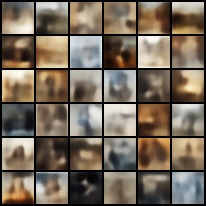

Epoch 25/100 | beta=0.100 | train: loss=0.5917, recon=0.5795, kl=0.1222 | 
Epoch 26/100 | beta=0.100 | train: loss=0.5917, recon=0.5795, kl=0.1222 | 
Epoch 27/100 | beta=0.100 | train: loss=0.5916, recon=0.5794, kl=0.1222 | 
Epoch 28/100 | beta=0.100 | train: loss=0.5916, recon=0.5794, kl=0.1221 | 
Epoch 29/100 | beta=0.100 | train: loss=0.5916, recon=0.5794, kl=0.1221 | 
Epoch 30/100 | beta=0.100 | train: loss=0.5915, recon=0.5793, kl=0.1220 | 
Epoch 31/100 | beta=0.100 | train: loss=0.5914, recon=0.5792, kl=0.1221 | 
Epoch 32/100 | beta=0.100 | train: loss=0.5915, recon=0.5792, kl=0.1222 | 
Epoch 33/100 | beta=0.100 | train: loss=0.5914, recon=0.5792, kl=0.1222 | 
Epoch 34/100 | beta=0.100 | train: loss=0.5914, recon=0.5792, kl=0.1222 | 
Epoch 35/100 | beta=0.100 | train: loss=0.5913, recon=0.5791, kl=0.1223 | 
Epoch 36/100 | beta=0.100 | train: loss=0.5912, recon=0.5790, kl=0.1222 | 
Epoch 37/100 | beta=0.100 | train: loss=0.5912, recon=0.5790, kl=0.1221 | 
Epoch 38/100 | beta=0.100

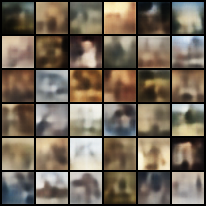

Epoch 50/100 | beta=0.100 | train: loss=0.5907, recon=0.5784, kl=0.1233 | 
Epoch 51/100 | beta=0.100 | train: loss=0.5907, recon=0.5783, kl=0.1234 | 
Epoch 52/100 | beta=0.100 | train: loss=0.5907, recon=0.5783, kl=0.1235 | 
Epoch 53/100 | beta=0.100 | train: loss=0.5907, recon=0.5783, kl=0.1234 | 
Epoch 54/100 | beta=0.100 | train: loss=0.5906, recon=0.5783, kl=0.1236 | 
Epoch 55/100 | beta=0.100 | train: loss=0.5906, recon=0.5782, kl=0.1236 | 
Epoch 56/100 | beta=0.100 | train: loss=0.5906, recon=0.5782, kl=0.1235 | 
Epoch 57/100 | beta=0.100 | train: loss=0.5904, recon=0.5781, kl=0.1237 | 
Epoch 58/100 | beta=0.100 | train: loss=0.5905, recon=0.5781, kl=0.1238 | 
Epoch 59/100 | beta=0.100 | train: loss=0.5905, recon=0.5781, kl=0.1237 | 
Epoch 60/100 | beta=0.100 | train: loss=0.5905, recon=0.5781, kl=0.1239 | 
Epoch 61/100 | beta=0.100 | train: loss=0.5904, recon=0.5780, kl=0.1237 | 
Epoch 62/100 | beta=0.100 | train: loss=0.5904, recon=0.5780, kl=0.1239 | 
Epoch 63/100 | beta=0.100

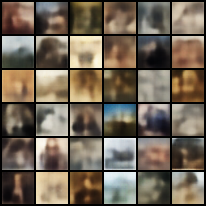

Epoch 75/100 | beta=0.100 | train: loss=0.5902, recon=0.5778, kl=0.1243 | 
Epoch 76/100 | beta=0.100 | train: loss=0.5902, recon=0.5778, kl=0.1243 | 
Epoch 77/100 | beta=0.100 | train: loss=0.5901, recon=0.5777, kl=0.1243 | 
Epoch 78/100 | beta=0.100 | train: loss=0.5901, recon=0.5777, kl=0.1243 | 
Epoch 79/100 | beta=0.100 | train: loss=0.5901, recon=0.5777, kl=0.1244 | 
Epoch 80/100 | beta=0.100 | train: loss=0.5901, recon=0.5777, kl=0.1241 | 
Epoch 81/100 | beta=0.100 | train: loss=0.5901, recon=0.5777, kl=0.1242 | 
Epoch 82/100 | beta=0.100 | train: loss=0.5901, recon=0.5777, kl=0.1243 | 
Epoch 83/100 | beta=0.100 | train: loss=0.5901, recon=0.5777, kl=0.1243 | 
Epoch 84/100 | beta=0.100 | train: loss=0.5901, recon=0.5777, kl=0.1244 | 
Epoch 85/100 | beta=0.100 | train: loss=0.5901, recon=0.5776, kl=0.1243 | 
Epoch 86/100 | beta=0.100 | train: loss=0.5901, recon=0.5776, kl=0.1243 | 
Epoch 87/100 | beta=0.100 | train: loss=0.5901, recon=0.5776, kl=0.1244 | 
Epoch 88/100 | beta=0.100

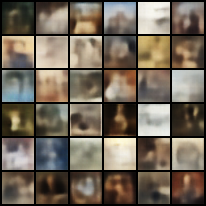

Epoch 100/100 | beta=0.100 | train: loss=0.5900, recon=0.5776, kl=0.1244 | 
----------------------------------------------------------------------------------------------------
Finished vae_ldim256_ep100_seed42 | best_train_loss=0.5900 | best_epoch=95 | time=44.5 min
----------------------------------------------------------------------------------------------------

VAE TRAINING FINISHED
latent_dim=256 | best_train_loss=0.5900 | best_epoch=95 | dir=c:\Users\User\source\repos\genai-project1\runs\vae_ldim256_ep100_seed42

Summary CSV saved to: c:\Users\User\source\repos\genai-project1\runs\summary_vae.csv


In [111]:
import os
import csv
import json
import gc
import time
from pathlib import Path

import torch
import torch.optim as optim
from torchvision.utils import save_image
from IPython.display import display as ipy_display, Image as IPyImage

# =========================
# Config
# =========================
latent_dim = 256

img_channels = 3
image_size = IMAGE_SIZE
hidden_dims = [32, 64, 128, 256]

learning_rate = 1e-3
weight_decay = 0.0
num_epochs = 100

beta_max = 0.1
warmup_epochs = 10

seed = 42
model_family = "vae"

# =========================
# Paths
# =========================
base_runs_dir = RUNS_DIR
base_runs_dir.mkdir(parents=True, exist_ok=True)

summary_csv_path = base_runs_dir / "summary_vae.csv"

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 100)
print(f"Device: {device}")
print(f"Train size: {len(train_loader.dataset)}")
print(f"Batch size: {train_loader.batch_size}")
print("=" * 100)


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def train_vae_for_latent_dim(latent_dim: int):
    run_name = f"vae_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
    run_dir = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    metrics_csv_path = run_dir / "metrics.csv"
    config_json_path = run_dir / "config.json"
    best_ckpt_path = run_dir / "best_model.pt"
    final_ckpt_path = run_dir / "final_model.pt"
    samples_dir = run_dir / "samples"
    samples_dir.mkdir(parents=True, exist_ok=True)

    config = {
        "run_name": run_name,
        "model_family": model_family,
        "seed": seed,
        "img_channels": img_channels,
        "image_size": image_size,
        "latent_dim": latent_dim,
        "hidden_dims": hidden_dims,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "num_epochs": num_epochs,
        "beta_max": beta_max,
        "warmup_epochs": warmup_epochs,
        "train_size": len(train_loader.dataset),
        "batch_size": train_loader.batch_size,
    }
    save_json(config, config_json_path)

    vae_model = VAE(
        img_channels=img_channels,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        image_size=image_size,
    ).to(device)

    optimizer = optim.Adam(
        vae_model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

    fieldnames = [
        "epoch",
        "beta",
        "train_loss",
        "train_recon",
        "train_kl",
    ]

    with open(metrics_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

    best_train_loss = float("inf")
    best_epoch = -1

    print("\n" + "=" * 100)
    print(f"Starting run: {run_name}")
    print(f"Run dir: {run_dir}")
    print("=" * 100)

    start_time = time.time()

    for epoch in range(num_epochs):
        beta = compute_beta_warmup(epoch, warmup_epochs, beta_max)

        # ---- TRAIN ----
        vae_model.train()
        train_loss_sum = 0.0
        train_recon_sum = 0.0
        train_kl_sum = 0.0
        train_num_batches = 0

        for batch in train_loader:
            x = batch[0].to(device, non_blocking=True)

            optimizer.zero_grad()

            reconstruction, mu, log_var = vae_model(x)
            loss, recon_loss, kl_loss = vae_loss(
                reconstruction, x, mu, log_var, beta=beta
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae_model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_sum += loss.item()
            train_recon_sum += recon_loss.item()
            train_kl_sum += kl_loss.item()
            train_num_batches += 1

        train_loss = train_loss_sum / train_num_batches
        train_recon = train_recon_sum / train_num_batches
        train_kl = train_kl_sum / train_num_batches

        scheduler.step()

        row = {
            "epoch": epoch + 1,
            "beta": beta,
            "train_loss": train_loss,
            "train_recon": train_recon,
            "train_kl": train_kl,
        }

        with open(metrics_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writerow(row)

        # ---- Save best ----
        if (epoch + 1) > warmup_epochs and train_loss < best_train_loss:
            best_train_loss = train_loss
            best_epoch = epoch + 1

            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": vae_model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_train_loss": best_train_loss,
                    "config": config,
                },
                best_ckpt_path,
            )

        if (epoch + 1) % 25 == 0:
            with torch.no_grad():
                z = torch.randn(36, latent_dim, device=device)
                samples = vae_model.decode(z).clamp(0.0, 1.0)
            _sp = samples_dir / f"samples_epoch_{epoch+1:03d}.png"
            save_image(samples, _sp, nrow=6)
            print(f"VAE samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(_sp), width=500))

        print(
            f"Epoch {epoch+1:>2}/{num_epochs} | "
            f"beta={beta:.3f} | "
            f"train: loss={train_loss:.4f}, recon={train_recon:.4f}, kl={train_kl:.4f} | "

        )

    total_time_sec = time.time() - start_time

    # ---- Save final checkpoint ----
    torch.save(
        {
            "epoch": num_epochs,
            "model_state_dict": vae_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_train_loss": best_train_loss,
            "best_epoch": best_epoch,
            "config": config,
        },
        final_ckpt_path,
    )

    summary_row = {
        "run_name": run_name,
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "best_epoch": best_epoch,
        "best_train_loss": best_train_loss,
        "train_size": len(train_loader.dataset),
        "batch_size": train_loader.batch_size,
        "beta_max": beta_max,
        "warmup_epochs": warmup_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "run_dir": str(run_dir),
        "best_ckpt_path": str(best_ckpt_path),
        "final_ckpt_path": str(final_ckpt_path),
        "time_sec": total_time_sec,
        "status": "ok",
    }

    print("-" * 100)
    print(
        f"Finished {run_name} | "
        f"best_train_loss={best_train_loss:.4f} | "
        f"best_epoch={best_epoch} | "
        f"time={total_time_sec/60:.1f} min"
    )
    print("-" * 100)

    return summary_row


# =========================
# Run all latent dims
# =========================
summary_fieldnames = [
    "run_name",
    "latent_dim",
    "num_epochs",
    "best_epoch",
    "best_train_loss",
    "train_size",
    "batch_size",
    "beta_max",
    "warmup_epochs",
    "learning_rate",
    "weight_decay",
    "run_dir",
    "best_ckpt_path",
    "final_ckpt_path",
    "time_sec",
    "status",
]

all_results = []

with open(summary_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writeheader()

try:
    result = train_vae_for_latent_dim(latent_dim)

except RuntimeError as e:
    result = {
        "run_name": f"vae_ldim{latent_dim}_ep{num_epochs}_seed{seed}",
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "best_epoch": None,
        "best_train_loss": None,
        "train_size": len(train_loader.dataset),
        "batch_size": train_loader.batch_size,
        "beta_max": beta_max,
        "warmup_epochs": warmup_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "run_dir": "",
        "best_ckpt_path": "",
        "final_ckpt_path": "",
        "time_sec": None,
        "status": f"runtime_error: {str(e)}",
    }
    print("\n" + "!" * 100)
    print(f"Run failed for latent_dim={latent_dim}")
    print(str(e))
    print("!" * 100)

with open(summary_csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writerow(result)

all_results.append(result)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =========================
# Final ranking print
# =========================
ok_results = [r for r in all_results if r["status"] == "ok" and r["best_train_loss"] is not None]
ok_results = sorted(ok_results, key=lambda x: x["best_train_loss"])

print("\n" + "=" * 100)
print("VAE TRAINING FINISHED")
print("=" * 100)

if all_results and all_results[0]["status"] == "ok":
    r = all_results[0]
    print(f"latent_dim={r['latent_dim']} | best_train_loss={r['best_train_loss']:.4f} | best_epoch={r['best_epoch']} | dir={r['run_dir']}")
else:
    print("Training failed.")

print(f"\nSummary CSV saved to: {summary_csv_path}")

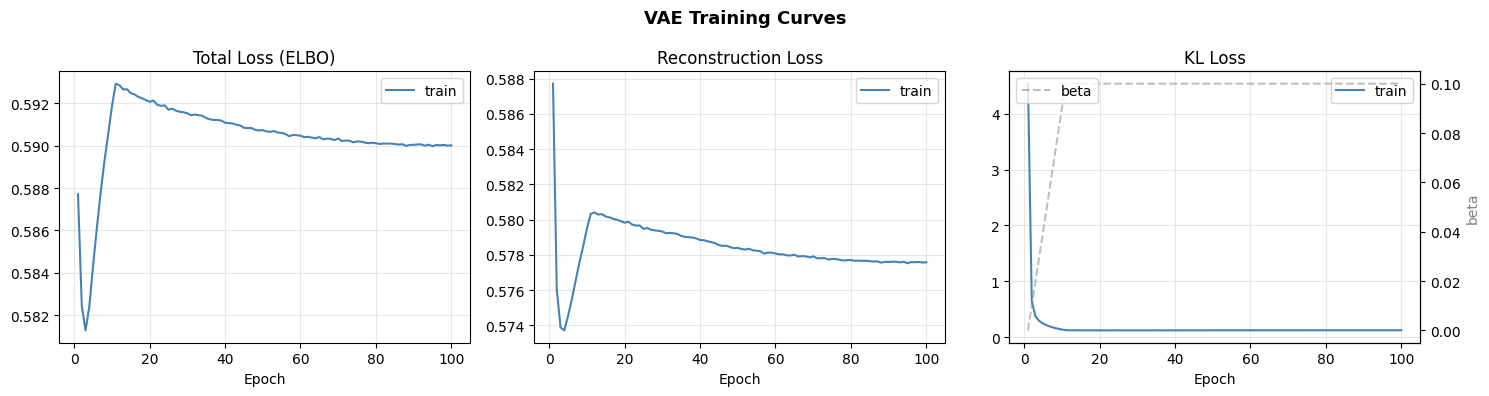

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\vae_training_curves.png


In [112]:
# VAE — Loss Curves
import csv
import matplotlib.pyplot as plt
from pathlib import Path

_runs = RUNS_DIR
_metrics = _runs / "vae_ldim256_ep100_seed42" / "metrics.csv"
_fig_dir = _runs / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)

if _metrics.exists():
    ep, tr_loss, tr_recon, tr_kl, betas = [], [], [], [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            tr_loss.append(float(row["train_loss"]))
            tr_recon.append(float(row["train_recon"]))
            tr_kl.append(float(row["train_kl"]))
            betas.append(float(row["beta"]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, tr, title in zip(axes,
        [tr_loss, tr_recon, tr_kl],
        ["Total Loss (ELBO)", "Reconstruction Loss", "KL Loss"]):
        ax.plot(ep, tr, label="train", color="steelblue")
        ax.set_title(title); ax.set_xlabel("Epoch")
        ax.legend(); ax.grid(True, alpha=0.3)

    ax2 = axes[2].twinx()
    ax2.plot(ep, betas, color="gray", linestyle="--", alpha=0.5, label="beta")
    ax2.set_ylabel("beta", color="gray"); ax2.legend(loc="upper left")

    fig.suptitle("VAE Training Curves", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(_fig_dir / "vae_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'vae_training_curves.png'}")
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


Run dir: c:\Users\User\source\repos\genai-project1\runs\vae_ldim256_ep100_seed42
Loaded epoch: 95 | best_train_loss: 0.5900


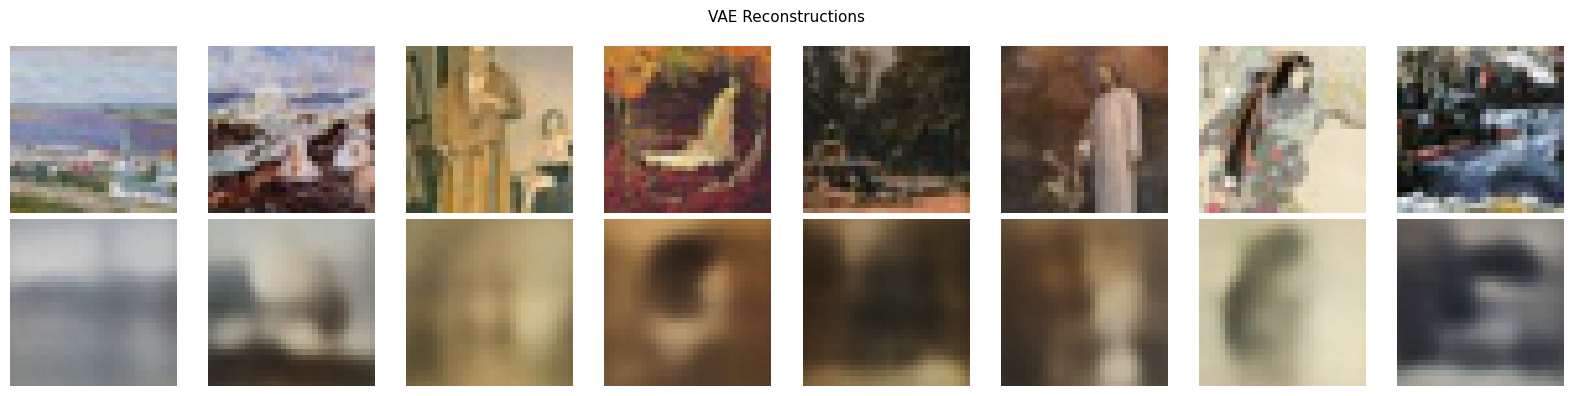

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\vae_reconstructions.png
Inference time (36 samples): 0.001s  |  0.0 ms/image


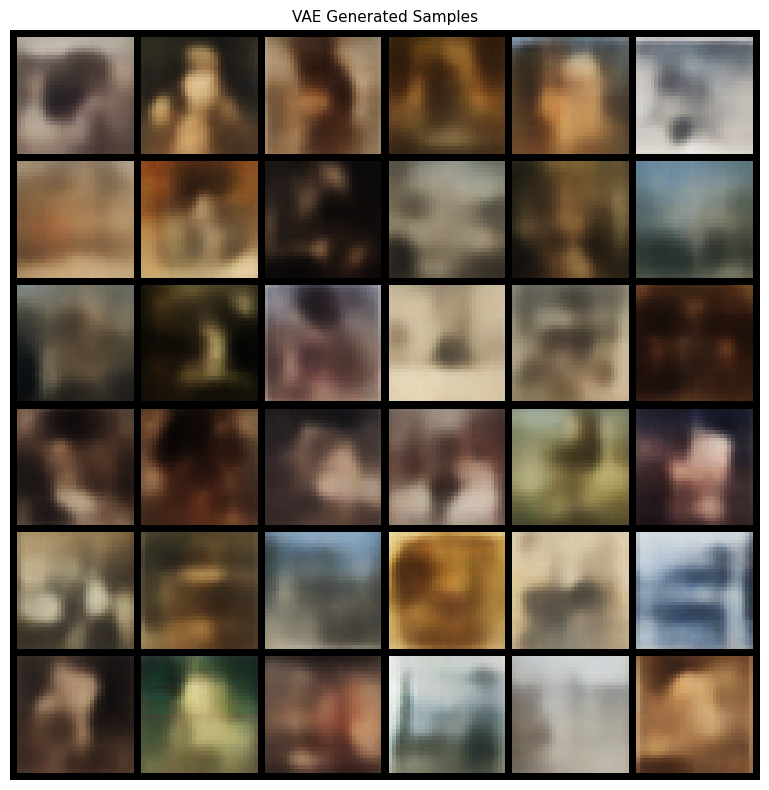

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\vae_samples.png


In [113]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image
from pathlib import Path

base_runs_dir = RUNS_DIR
_fig_dir = base_runs_dir / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 256
num_epochs = 100
seed = 42


def save_image_grid(images, save_path, n_images=36, nrow=6, title=""):
    images = images[:n_images].detach().cpu().clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).numpy()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(np_img); ax.axis("off")
    if title: ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def save_reconstructions(model, x, save_path, title="", n_show=8):
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(x)
    fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
    for i in range(n_show):
        axes[0, i].imshow(x[i].detach().cpu().permute(1, 2, 0).numpy())
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy())
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=9)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=9)
    if title: fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


x_batch, _, _ = next(iter(train_loader))
x_batch = x_batch[:8].to(device)

run_name = f"vae_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
run_dir = base_runs_dir / run_name
best_ckpt_path = run_dir / "best_model.pt"
print(f"Run dir: {run_dir}")

if not best_ckpt_path.exists():
    print(f"Checkpoint not found: {best_ckpt_path}")
else:
    vae_model = VAE(
        img_channels=3, latent_dim=latent_dim,
        hidden_dims=[32, 64, 128, 256], image_size=IMAGE_SIZE,
    ).to(device)

    checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    vae_model.load_state_dict(checkpoint["model_state_dict"])
    vae_model.eval()

    print(f"Loaded epoch: {checkpoint['epoch']} | best_train_loss: {checkpoint.get('best_train_loss', checkpoint.get('best_val_loss', '?')):.4f}")

    save_reconstructions(vae_model, x_batch,
        save_path=_fig_dir / "vae_reconstructions.png",
        title="VAE Reconstructions")

    import time as _time_mod
    # ── Inference timing ────────────────────────────────────────────
    with torch.no_grad():  # GPU warmup
        _ = vae_model.sample(4, device=device)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.time()
    with torch.no_grad():
        samples = vae_model.sample(36, device=device)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _infer_time = _time_mod.time() - _t0
    print(f"Inference time (36 samples): {_infer_time:.3f}s  |  {_infer_time/36*1000:.1f} ms/image")
    import json as _jj
    _it_path = base_runs_dir / "inference_times.json"
    _it = _jj.load(open(_it_path)) if _it_path.exists() else {}
    _it["vae"] = {"time_36_samples_sec": round(_infer_time, 4), "ms_per_image": round(_infer_time/36*1000, 2)}
    _jj.dump(_it, open(_it_path, "w"), indent=2)

    save_image_grid(samples, save_path=_fig_dir / "vae_samples.png",
        n_images=36, nrow=6, title="VAE Generated Samples")


In [114]:
# ── VAE — FID/KID ────────────────────────────────────────────────
_vae_row       = _best_row(_runs / "summary_vae.csv", "best_train_loss")
_vae_ckpt_path = Path(_vae_row["best_ckpt_path"]) if _vae_row else None

if _vae_ckpt_path and _vae_ckpt_path.exists():
    print(f"[VAE] Loading from: {_vae_ckpt_path}")
    _ckpt  = torch.load(_vae_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = VAE(
        img_channels=_cfg["img_channels"],
        image_size=_cfg["image_size"],
        latent_dim=_cfg["latent_dim"],
        hidden_dims=_cfg["hidden_dims"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="vae",
        latent_dim=_cfg["latent_dim"],
        img_channels=_cfg["img_channels"], img_size=_cfg["image_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    _all = _load_results()
    _all["vae"] = _res
    _save_results(_all)
    _print_results({"vae": _res})
else:
    print(f"[VAE] Checkpoint not found — skipping. (path={_vae_ckpt_path})")


[VAE] Loading from: c:\Users\User\source\repos\genai-project1\runs\vae_ldim256_ep100_seed42\best_model.pt


c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  [vae] Rep 1/10 seed=0 | FID=194.35 | KID=185.2067±10.8316 (×10⁻³)
  [vae] Rep 2/10 seed=137 | FID=194.39 | KID=185.6588±8.6683 (×10⁻³)
  [vae] Rep 3/10 seed=274 | FID=195.74 | KID=184.5185±9.0776 (×10⁻³)
  [vae] Rep 4/10 seed=411 | FID=195.86 | KID=187.5209±10.2047 (×10⁻³)
  [vae] Rep 5/10 seed=548 | FID=194.61 | KID=185.0932±9.3075 (×10⁻³)
  [vae] Rep 6/10 seed=685 | FID=197.08 | KID=185.5094±7.4556 (×10⁻³)
  [vae] Rep 7/10 seed=822 | FID=195.94 | KID=187.1475±10.4192 (×10⁻³)
  [vae] Rep 8/10 seed=959 | FID=195.15 | KID=184.4464±8.4571 (×10⁻³)
  [vae] Rep 9/10 seed=1096 | FID=196.95 | KID=185.8408±11.0229 (×10⁻³)
  [vae] Rep 10/10 seed=1233 | FID=196.89 | KID=188.8327±10.3735 (×10⁻³)

  VAE | FID: 195.70 ± 1.00 | KID: 185.9775 ± 1.3450 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--------------------------------------------------------
VAE              195.70     1.00     185.9775 

---
## DCGAN

In [17]:
import torch
import torch.nn as nn


class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int = 128,
        img_channels: int = 3,
        img_size: int = 32,
        hidden_dims: list[int] = [32, 64, 128, 256],
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.img_size = img_size
        self.img_channels = img_channels
        self.hidden_dims = hidden_dims

        # For img_size=32 and 4 upsampling blocks:
        # 32 -> 16 -> 8 -> 4 -> 2 (encoder view)
        # so generator starts from 2x2 and upsamples back to 32x32
        self.initial_spatial_dim = img_size // (2 ** len(hidden_dims))
        if self.initial_spatial_dim < 1:
            raise ValueError(
                f"img_size={img_size} too small for {len(hidden_dims)} upsampling layers"
            )

        self.initial_channels = hidden_dims[-1]

        # Project z -> initial feature map
        self.initial_projection = nn.Linear(
            latent_dim,
            self.initial_channels * (self.initial_spatial_dim ** 2)
        )

        modules = []
        reversed_hidden_dims = hidden_dims[::-1]  # e.g. [256, 128, 64, 32]

        in_channels = reversed_hidden_dims[0]
        for i in range(len(reversed_hidden_dims) - 1):
            out_channels = reversed_hidden_dims[i + 1]
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        in_channels,
                        out_channels,
                        kernel_size=4,
                        stride=2,
                        padding=1,
                        bias=False,
                    ),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(True),
                )
            )
            in_channels = out_channels

        # Final upsampling to image
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(
                    in_channels,
                    img_channels,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    bias=False,
                ),
                nn.Tanh(),  # output in [-1, 1]
            )
        )

        self.main = nn.Sequential(*modules)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.initial_projection(z)
        x = x.view(
            -1,
            self.initial_channels,
            self.initial_spatial_dim,
            self.initial_spatial_dim,
        )
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] = [32, 64, 128, 256],
    ):
        super().__init__()

        modules = []

        # First block: no BatchNorm (standard DCGAN practice)
        modules.append(
            nn.Sequential(
                nn.Conv2d(
                    img_channels,
                    hidden_dims[0],
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    bias=False,
                ),
                nn.LeakyReLU(0.2, inplace=True),
            )
        )

        in_channels = hidden_dims[0]

        for i in range(1, len(hidden_dims)):
            out_channels = hidden_dims[i]
            modules.append(
                nn.Sequential(
                    nn.Conv2d(
                        in_channels,
                        out_channels,
                        kernel_size=4,
                        stride=2,
                        padding=1,
                        bias=False,
                    ),
                    nn.BatchNorm2d(out_channels),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )
            in_channels = out_channels

        self.main = nn.Sequential(*modules)

        # For 32x32 with 4 downsampling blocks:
        # 32 -> 16 -> 8 -> 4 -> 2
        # final 2x2 -> 1x1 scalar
        self.final_conv = nn.Conv2d(
            in_channels,
            1,
            kernel_size=2,
            stride=1,
            padding=0,
            bias=False,
        )

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        x = self.main(img)
        x = self.final_conv(x)
        return x.view(-1)  # raw logits


def dcgan_weights_init(m):
    """
    DCGAN-style weight initialization.
    """
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)

In [ ]:
_g = Generator(latent_dim=256, img_channels=3, img_size=32,
               hidden_dims=[32, 64, 128, 256])
_d = Discriminator(img_channels=3, hidden_dims=[32, 64, 128, 256])
print("=== Generator ==="); print(_g)
print(f"\nGenerator params: {sum(p.numel() for p in _g.parameters()):,}")
print("\n=== Discriminator ==="); print(_d)
print(f"\nDiscriminator params: {sum(p.numel() for p in _d.parameters()):,}")
del _g, _d

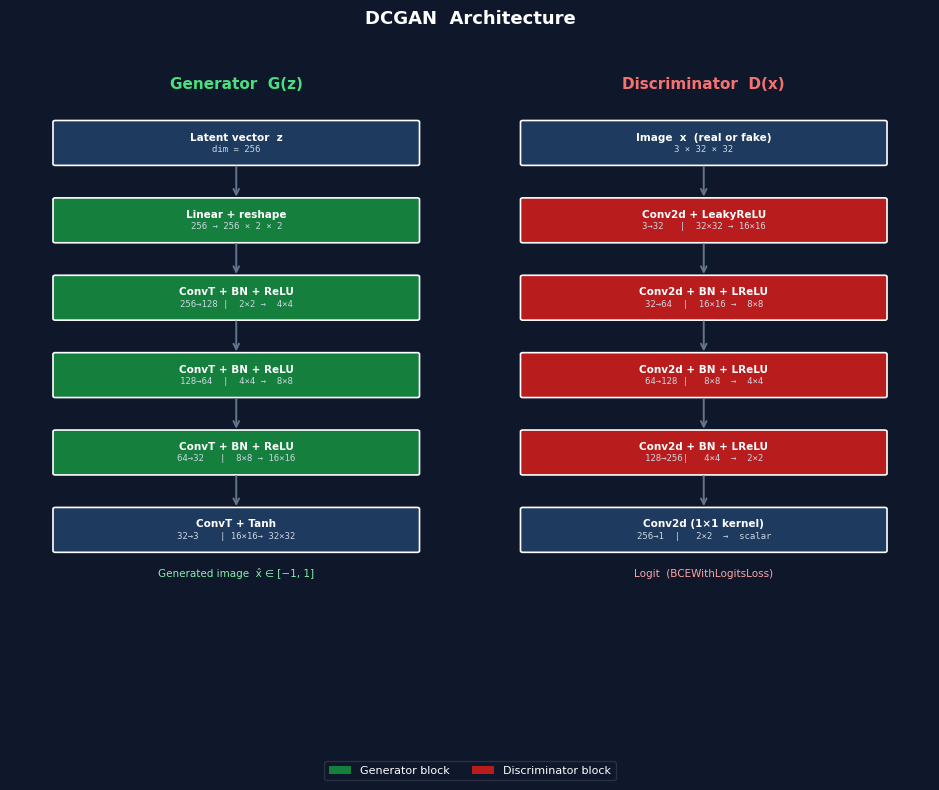

Saved: runs/figures/arch_dcgan.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

BG  = "#0F172A"
GEN = "#15803D"   # green
DIS = "#B91C1C"   # red
IO  = "#1E3A5F"
ARR = "#64748B"

def _box(ax, cx, cy, w, h, label, sub, color):
    p = FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                       boxstyle="round,pad=0.02",
                       fc=color, ec="white", lw=1.2, zorder=3)
    ax.add_patch(p)
    dy = h*0.14 if sub else 0
    ax.text(cx, cy+dy, label, ha="center", va="center",
            fontsize=7.5, fontweight="bold", color="white", zorder=4)
    if sub:
        ax.text(cx, cy-dy, sub, ha="center", va="center",
                fontsize=6.5, color="#CBD5E1", zorder=4, family="monospace")

def _arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color=ARR, lw=1.4,
                                mutation_scale=10), zorder=5)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 8))
fig.patch.set_facecolor(BG)
fig.suptitle("DCGAN  Architecture", fontsize=13, fontweight="bold",
             color="white", y=0.98)

W, H = 3.2, 0.54

# ── Generator ────────────────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor(BG); ax.axis("off")
ax.set_xlim(0, 4); ax.set_ylim(-0.3, 8.5)
ax.text(2.0, 8.2, "Generator  G(z)", ha="center", fontsize=11,
        fontweight="bold", color="#4ADE80")

gen_layers = [
    (7.5, "Latent vector  z", "dim = 256",            IO),
    (6.5, "Linear + reshape", "256 → 256 × 2 × 2",   GEN),
    (5.5, "ConvT + BN + ReLU","256→128 |  2×2 →  4×4", GEN),
    (4.5, "ConvT + BN + ReLU","128→64  |  4×4 →  8×8", GEN),
    (3.5, "ConvT + BN + ReLU","64→32   |  8×8 → 16×16",GEN),
    (2.5, "ConvT + Tanh",     "32→3    | 16×16→ 32×32",IO),
]
for (y, lbl, sub, col) in gen_layers:
    _box(ax, 2.0, y, W, H, lbl, sub, col)
for i in range(len(gen_layers)-1):
    _arrow(ax, 2.0, gen_layers[i][0]-H/2, 2.0, gen_layers[i+1][0]+H/2)

ax.text(2.0, 1.9, "Generated image  x̂ ∈ [−1, 1]", ha="center",
        fontsize=7.5, color="#86EFAC")

# ── Discriminator ─────────────────────────────────────────────────────────────
ax = axes[1]; ax.set_facecolor(BG); ax.axis("off")
ax.set_xlim(0, 4); ax.set_ylim(-0.3, 8.5)
ax.text(2.0, 8.2, "Discriminator  D(x)", ha="center", fontsize=11,
        fontweight="bold", color="#F87171")

dis_layers = [
    (7.5, "Image  x  (real or fake)", "3 × 32 × 32",           IO),
    (6.5, "Conv2d + LeakyReLU",       "3→32   |  32×32 → 16×16", DIS),
    (5.5, "Conv2d + BN + LReLU",      "32→64  |  16×16 →  8×8",  DIS),
    (4.5, "Conv2d + BN + LReLU",      "64→128 |   8×8  →  4×4",  DIS),
    (3.5, "Conv2d + BN + LReLU",      "128→256|   4×4  →  2×2",  DIS),
    (2.5, "Conv2d (1×1 kernel)",       "256→1  |   2×2  →  scalar", IO),
]
for (y, lbl, sub, col) in dis_layers:
    _box(ax, 2.0, y, W, H, lbl, sub, col)
for i in range(len(dis_layers)-1):
    _arrow(ax, 2.0, dis_layers[i][0]-H/2, 2.0, dis_layers[i+1][0]+H/2)

ax.text(2.0, 1.9, "Logit  (BCEWithLogitsLoss)", ha="center",
        fontsize=7.5, color="#FCA5A5")

handles = [mpatches.Patch(fc=GEN, label="Generator block"),
           mpatches.Patch(fc=DIS, label="Discriminator block")]
fig.legend(handles=handles, loc="lower center", ncol=2, framealpha=0.15,
           labelcolor="white", fontsize=8, facecolor=BG, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig("runs/figures/arch_dcgan.png", dpi=180, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Saved: runs/figures/arch_dcgan.png")


## Train DCGAN (Full 50k)

Device: cuda | Train size: 50,000

Starting: dcgan_full_ep100_seed42  (50,000 images, 100 epochs)
[DCGAN-full] Epoch   1/100 | D=0.6413 | G=3.8388 | D(real)=0.7866 | D(fake)=0.0730
[DCGAN-full] Epoch   2/100 | D=0.8274 | G=3.3870 | D(real)=0.7365 | D(fake)=0.0758
[DCGAN-full] Epoch   3/100 | D=0.8082 | G=3.5020 | D(real)=0.7668 | D(fake)=0.0886
[DCGAN-full] Epoch   4/100 | D=0.8738 | G=4.0335 | D(real)=0.7698 | D(fake)=0.0840
[DCGAN-full] Epoch   5/100 | D=0.9351 | G=3.4784 | D(real)=0.7353 | D(fake)=0.1068
[DCGAN-full] Epoch   6/100 | D=0.9065 | G=3.2441 | D(real)=0.7521 | D(fake)=0.1289
[DCGAN-full] Epoch   7/100 | D=0.9359 | G=3.6264 | D(real)=0.7628 | D(fake)=0.1339
[DCGAN-full] Epoch   8/100 | D=0.9576 | G=4.0748 | D(real)=0.7547 | D(fake)=0.1206
[DCGAN-full] Epoch   9/100 | D=0.8187 | G=4.6352 | D(real)=0.8011 | D(fake)=0.0956
[DCGAN-full] Epoch  10/100 | D=0.7866 | G=5.5260 | D(real)=0.8220 | D(fake)=0.0854
[DCGAN-full] Epoch  11/100 | D=0.8381 | G=5.9498 | D(real)=0.8349 | D(fa

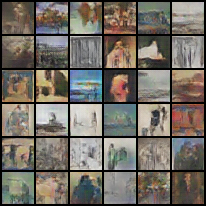

[DCGAN-full] Epoch  25/100 | D=0.6397 | G=13.4580 | D(real)=0.9024 | D(fake)=0.0426
[DCGAN-full] Epoch  26/100 | D=0.5395 | G=15.0755 | D(real)=0.9246 | D(fake)=0.0327
[DCGAN-full] Epoch  27/100 | D=0.4721 | G=15.7682 | D(real)=0.9339 | D(fake)=0.0283
[DCGAN-full] Epoch  28/100 | D=0.4206 | G=16.6462 | D(real)=0.9376 | D(fake)=0.0228
[DCGAN-full] Epoch  29/100 | D=0.5326 | G=17.8956 | D(real)=0.9230 | D(fake)=0.0236
[DCGAN-full] Epoch  30/100 | D=0.3614 | G=18.9873 | D(real)=0.9397 | D(fake)=0.0123
[DCGAN-full] Epoch  31/100 | D=0.3297 | G=19.9405 | D(real)=0.9507 | D(fake)=0.0150
[DCGAN-full] Epoch  32/100 | D=0.3711 | G=21.1338 | D(real)=0.9410 | D(fake)=0.0124
[DCGAN-full] Epoch  33/100 | D=0.3690 | G=22.2146 | D(real)=0.9392 | D(fake)=0.0094
[DCGAN-full] Epoch  34/100 | D=0.2562 | G=22.6940 | D(real)=0.9493 | D(fake)=0.0058
[DCGAN-full] Epoch  35/100 | D=0.4775 | G=24.2521 | D(real)=0.9246 | D(fake)=0.0057
[DCGAN-full] Epoch  36/100 | D=0.3995 | G=23.3700 | D(real)=0.9452 | D(fake)

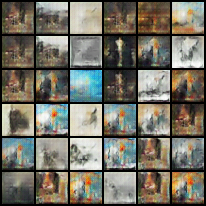

[DCGAN-full] Epoch  50/100 | D=0.1404 | G=27.3156 | D(real)=0.9714 | D(fake)=0.0038
[DCGAN-full] Epoch  51/100 | D=0.1590 | G=26.9776 | D(real)=0.9755 | D(fake)=0.0043
[DCGAN-full] Epoch  52/100 | D=0.1785 | G=27.6042 | D(real)=0.9690 | D(fake)=0.0034
[DCGAN-full] Epoch  53/100 | D=0.1909 | G=27.8154 | D(real)=0.9734 | D(fake)=0.0039
[DCGAN-full] Epoch  54/100 | D=0.1685 | G=28.9659 | D(real)=0.9732 | D(fake)=0.0025
[DCGAN-full] Epoch  55/100 | D=0.1625 | G=29.8114 | D(real)=0.9689 | D(fake)=0.0012
[DCGAN-full] Epoch  56/100 | D=0.1177 | G=28.2182 | D(real)=0.9753 | D(fake)=0.0014
[DCGAN-full] Epoch  57/100 | D=0.2294 | G=27.7690 | D(real)=0.9697 | D(fake)=0.0049
[DCGAN-full] Epoch  58/100 | D=0.1693 | G=27.4339 | D(real)=0.9698 | D(fake)=0.0020
[DCGAN-full] Epoch  59/100 | D=0.1363 | G=29.1053 | D(real)=0.9782 | D(fake)=0.0029
[DCGAN-full] Epoch  60/100 | D=0.2025 | G=29.3581 | D(real)=0.9711 | D(fake)=0.0039
[DCGAN-full] Epoch  61/100 | D=0.1910 | G=29.7254 | D(real)=0.9762 | D(fake)

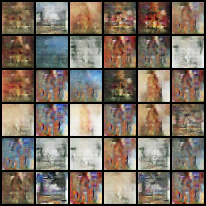

[DCGAN-full] Epoch  75/100 | D=0.1162 | G=30.9001 | D(real)=0.9793 | D(fake)=0.0014
[DCGAN-full] Epoch  76/100 | D=0.1202 | G=31.0395 | D(real)=0.9820 | D(fake)=0.0043
[DCGAN-full] Epoch  77/100 | D=0.1125 | G=32.8015 | D(real)=0.9780 | D(fake)=0.0006
[DCGAN-full] Epoch  78/100 | D=0.1315 | G=31.9768 | D(real)=0.9794 | D(fake)=0.0039
[DCGAN-full] Epoch  79/100 | D=0.1972 | G=30.6388 | D(real)=0.9774 | D(fake)=0.0059
[DCGAN-full] Epoch  80/100 | D=0.1570 | G=30.9299 | D(real)=0.9759 | D(fake)=0.0026
[DCGAN-full] Epoch  81/100 | D=0.0849 | G=31.9346 | D(real)=0.9852 | D(fake)=0.0013
[DCGAN-full] Epoch  82/100 | D=0.1649 | G=31.1520 | D(real)=0.9776 | D(fake)=0.0031
[DCGAN-full] Epoch  83/100 | D=0.1439 | G=31.7215 | D(real)=0.9794 | D(fake)=0.0028
[DCGAN-full] Epoch  84/100 | D=0.2217 | G=33.6676 | D(real)=0.9751 | D(fake)=0.0038
[DCGAN-full] Epoch  85/100 | D=0.1679 | G=30.7938 | D(real)=0.9807 | D(fake)=0.0044
[DCGAN-full] Epoch  86/100 | D=0.1723 | G=29.7603 | D(real)=0.9733 | D(fake)

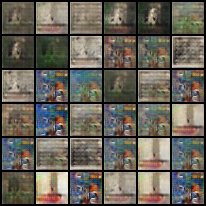

[DCGAN-full] Epoch 100/100 | D=0.1252 | G=29.3151 | D(real)=0.9785 | D(fake)=0.0019

Finished dcgan_full_ep100_seed42 | time=51.8 min
Summary CSV: c:\Users\User\source\repos\genai-project1\runs\summary_dcgan_full.csv


In [116]:
import os, csv, json, gc, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image, make_grid
from IPython.display import display as ipy_display, Image as IPyImage

# ── Config (same as subset run) ──────────────────────────────────
latent_dim    = 256
img_channels  = 3
img_size      = IMAGE_SIZE
hidden_dims   = [32, 64, 128, 256]
learning_rate = 2e-4
beta1, beta2  = 0.5, 0.999
num_epochs    = 100
seed          = 42

base_runs_dir    = RUNS_DIR
base_runs_dir.mkdir(parents=True, exist_ok=True)
summary_csv_path = base_runs_dir / "summary_dcgan_full.csv"
device           = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device} | Train size: {len(train_loader_full.dataset):,}")


def _save_sample_grid_full(G, noise, save_path, nrow=6):
    G.eval()
    with torch.no_grad():
        fake = G(noise).detach().cpu()
    fake = ((fake + 1.0) / 2.0).clamp(0, 1)
    save_image(make_grid(fake, nrow=nrow, padding=2), save_path)
    G.train()


def train_dcgan_full():
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    run_name = f"dcgan_full_ep{num_epochs}_seed{seed}"
    run_dir  = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    metrics_csv  = run_dir / "metrics.csv"
    config_json  = run_dir / "config.json"
    final_g_path = run_dir / "final_generator.pt"
    final_d_path = run_dir / "final_discriminator.pt"
    samples_dir  = run_dir / "samples"
    samples_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir = run_dir / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    config = {
        "run_name": run_name, "model_family": "dcgan", "seed": seed,
        "latent_dim": latent_dim, "img_channels": img_channels,
        "img_size": img_size, "hidden_dims": hidden_dims,
        "learning_rate": learning_rate, "beta1": beta1, "beta2": beta2,
        "num_epochs": num_epochs,
        "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size,
    }
    with open(config_json, "w") as f:
        json.dump(config, f, indent=2)

    G = Generator(
        latent_dim=latent_dim, img_channels=img_channels,
        img_size=img_size, hidden_dims=hidden_dims,
    ).to(device)
    D = Discriminator(
        img_channels=img_channels, hidden_dims=hidden_dims,
    ).to(device)
    G.apply(dcgan_weights_init)
    D.apply(dcgan_weights_init)

    criterion   = nn.BCEWithLogitsLoss()
    optimizer_G = optim.Adam(G.parameters(), lr=learning_rate, betas=(beta1, beta2))
    optimizer_D = optim.Adam(D.parameters(), lr=learning_rate, betas=(beta1, beta2))
    fixed_noise = torch.randn(36, latent_dim, device=device)

    fieldnames = ["epoch", "d_loss", "g_loss", "d_real_mean", "d_fake_mean"]
    with open(metrics_csv, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=fieldnames).writeheader()

    print("\n" + "=" * 100)
    print(f"Starting: {run_name}  ({len(train_loader_full.dataset):,} images, {num_epochs} epochs)")
    print("=" * 100)

    start_time = time.time()

    for epoch in range(num_epochs):
        G.train(); D.train()
        d_sum = g_sum = dr_sum = df_sum = 0.0
        nb = 0

        for batch in train_loader_full:
            real_imgs = batch[0].to(device, non_blocking=True)
            bs = real_imgs.size(0)
            real_t = torch.ones(bs,  device=device)
            fake_t = torch.zeros(bs, device=device)

            # D step
            optimizer_D.zero_grad()
            rl = D(real_imgs)
            d_real = criterion(rl, real_t)
            z = torch.randn(bs, latent_dim, device=device)
            fi = G(z)
            fl = D(fi.detach())
            d_fake = criterion(fl, fake_t)
            d_loss = d_real + d_fake
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
            optimizer_D.step()

            # G step
            optimizer_G.zero_grad()
            flg = D(fi)
            g_loss = criterion(flg, real_t)
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
            optimizer_G.step()

            d_sum  += d_loss.item(); g_sum  += g_loss.item()
            dr_sum += torch.sigmoid(rl).mean().item()
            df_sum += torch.sigmoid(flg).mean().item()
            nb += 1

        d_e = d_sum/nb; g_e = g_sum/nb
        dr_e = dr_sum/nb; df_e = df_sum/nb

        with open(metrics_csv, "a", newline="") as f:
            csv.DictWriter(f, fieldnames=fieldnames).writerow({
                "epoch": epoch+1, "d_loss": d_e, "g_loss": g_e,
                "d_real_mean": dr_e, "d_fake_mean": df_e,
            })

        if (epoch + 1) % 5 == 0:
            torch.save({"epoch": epoch+1, "generator_state_dict": G.state_dict(),
                        "discriminator_state_dict": D.state_dict(), "config": config},
                       ckpt_dir / f"checkpoint_epoch_{epoch+1:03d}.pt")

        if (epoch + 1) % 25 == 0:
            sp = samples_dir / f"epoch_{epoch+1:03d}.png"
            _save_sample_grid_full(G, fixed_noise, sp)
            print(f"Samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(sp), width=500))

        print(
            f"[DCGAN-full] Epoch {epoch+1:>3}/{num_epochs} | "
            f"D={d_e:.4f} | G={g_e:.4f} | "
            f"D(real)={dr_e:.4f} | D(fake)={df_e:.4f}"
        )

    total_time = time.time() - start_time

    torch.save({"epoch": num_epochs, "model_state_dict": G.state_dict(),
                "optimizer_state_dict": optimizer_G.state_dict(),
                "final_g_loss": g_e, "config": config}, final_g_path)
    torch.save({"epoch": num_epochs, "model_state_dict": D.state_dict(),
                "optimizer_state_dict": optimizer_D.state_dict(),
                "config": config}, final_d_path)

    summary_row = {
        "run_name": run_name, "latent_dim": latent_dim, "num_epochs": num_epochs,
        "final_g_loss": g_e, "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size, "learning_rate": learning_rate,
        "beta1": beta1, "beta2": beta2, "run_dir": str(run_dir),
        "final_g_path": str(final_g_path), "final_d_path": str(final_d_path),
        "time_sec": total_time, "status": "ok",
    }
    print(f"\nFinished {run_name} | time={total_time/60:.1f} min")
    return summary_row


summary_fieldnames = [
    "run_name", "latent_dim", "num_epochs", "final_g_loss", "train_size",
    "batch_size", "learning_rate", "beta1", "beta2", "run_dir",
    "final_g_path", "final_d_path", "time_sec", "status",
]

with open(summary_csv_path, "w", newline="") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writeheader()

try:
    result = train_dcgan_full()
except RuntimeError as e:
    result = {
        "run_name": f"dcgan_full_ep{num_epochs}_seed{seed}", "latent_dim": latent_dim,
        "num_epochs": num_epochs, "final_g_loss": None,
        "train_size": len(train_loader_full.dataset), "batch_size": train_loader_full.batch_size,
        "learning_rate": learning_rate, "beta1": beta1, "beta2": beta2,
        "run_dir": "", "final_g_path": "", "final_d_path": "",
        "time_sec": None, "status": f"runtime_error: {str(e)}",
    }
    print(f"Training failed: {e}")

with open(summary_csv_path, "a", newline="") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writerow(result)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f"Summary CSV: {summary_csv_path}")


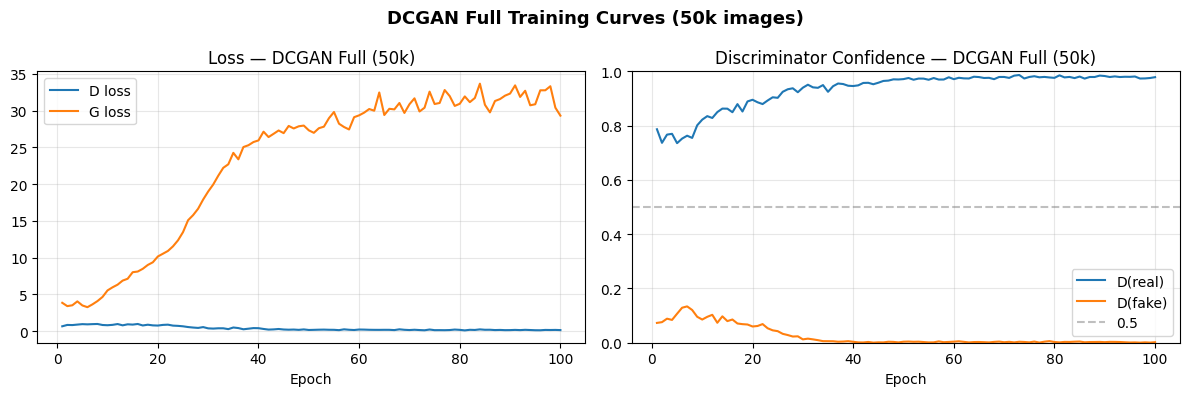

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\dcgan_full_training_curves.png


In [117]:
# DCGAN Full — Loss Curves
import csv
import matplotlib.pyplot as plt
from pathlib import Path

_runs    = RUNS_DIR
_metrics = _runs / "dcgan_full_ep100_seed42" / "metrics.csv"

if _metrics.exists():
    ep, d_loss, g_loss, d_real, d_fake = [], [], [], [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            d_loss.append(float(row["d_loss"]));      g_loss.append(float(row["g_loss"]))
            d_real.append(float(row["d_real_mean"])); d_fake.append(float(row["d_fake_mean"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(ep, d_loss, label="D loss")
    axes[0].plot(ep, g_loss, label="G loss")
    axes[0].set_title("Loss — DCGAN Full (50k)")
    axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, d_real, label="D(real)")
    axes[1].plot(ep, d_fake, label="D(fake)")
    axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="0.5")
    axes[1].set_title("Discriminator Confidence — DCGAN Full (50k)")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylim(0, 1)
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    fig.suptitle("DCGAN Full Training Curves (50k images)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    _fig_dir = _runs / "figures"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_fig_dir / "dcgan_full_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'dcgan_full_training_curves.png'}")
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


Loaded epoch 100 | G loss: 29.3151
Inference (36 samples): 0.001s | 0.0 ms/image
Saved: c:\Users\User\source\repos\genai-project1\runs\figures\dcgan_full_samples.png


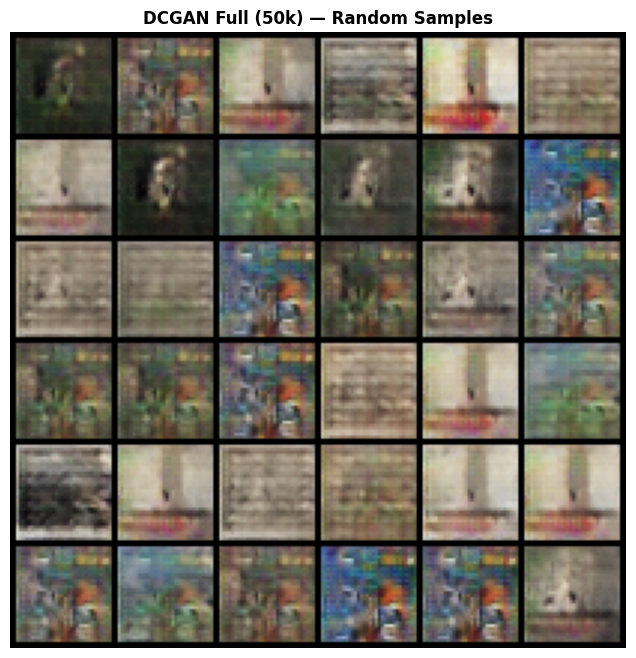

In [118]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path
import time as _time_mod

base_runs_dir = RUNS_DIR
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 256; num_epochs = 100; seed = 42

ckpt_path = base_runs_dir / "dcgan_full_ep100_seed42" / "final_generator.pt"

if not ckpt_path.exists():
    print(f"Checkpoint not found: {ckpt_path}")
else:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg  = ckpt["config"]
    G = Generator(
        latent_dim=cfg["latent_dim"], img_channels=cfg["img_channels"],
        img_size=cfg["img_size"], hidden_dims=cfg["hidden_dims"],
    ).to(device)
    G.load_state_dict(ckpt["model_state_dict"])
    G.eval()
    print(f"Loaded epoch {ckpt['epoch']} | G loss: {ckpt['final_g_loss']:.4f}")

    # Inference timing
    with torch.no_grad():
        _ = G(torch.randn(4, cfg["latent_dim"], device=device))
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.time()
    with torch.no_grad():
        z = torch.randn(36, cfg["latent_dim"], device=device)
        samples = G(z)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _infer_time = _time_mod.time() - _t0
    print(f"Inference (36 samples): {_infer_time:.3f}s | {_infer_time/36*1000:.1f} ms/image")

    imgs = ((samples.detach().cpu() + 1.0) / 2.0).clamp(0, 1)
    grid = make_grid(imgs[:36], nrow=6, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title("DCGAN Full (50k) — Random Samples", fontsize=12, fontweight="bold")
    _fig_dir = base_runs_dir / "figures"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_fig_dir / "dcgan_full_samples.png", dpi=150, bbox_inches="tight")
    print(f"Saved: {_fig_dir / 'dcgan_full_samples.png'}")
    plt.show()


In [119]:
# ── DCGAN Full — FID/KID ─────────────────────────────────────────
_full_ckpt = _runs / "dcgan_full_ep100_seed42" / "final_generator.pt"

if _full_ckpt.exists():
    print(f"[DCGAN-full] Loading from: {_full_ckpt}")
    _ckpt  = torch.load(_full_ckpt, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = Generator(
        latent_dim=_cfg["latent_dim"], img_channels=_cfg["img_channels"],
        img_size=_cfg["img_size"],     hidden_dims=_cfg["hidden_dims"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="gan",
        latent_dim=_cfg["latent_dim"],
        img_channels=_cfg["img_channels"], img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    _all = _load_results()
    _all["dcgan_full"] = _res
    _save_results(_all)
    _print_results({"dcgan_full": _res})

    # Compare subset vs full
    print("\n── Subset vs Full dataset ───────────────────────────────────")
    print(f"{'Config':<28} {'FID':>8} {'FID±':>7} {'KID×10³':>10}")
    print("-" * 58)
    for key, label in [
        ("gan",        "DCGAN subset (10k)  "),
        ("dcgan_full", "DCGAN full   (50k)  "),
    ]:
        if key in _all:
            r = _all[key]
            print(f"{label:<28} {r['fid_mean']:>8.2f} {r['fid_std']:>7.2f} {r['kid_mean']*1e3:>10.2f}")
else:
    print(f"[DCGAN-full] Checkpoint not found at {_full_ckpt} — run training first.")


[DCGAN-full] Loading from: c:\Users\User\source\repos\genai-project1\runs\dcgan_full_ep100_seed42\final_generator.pt
  [gan] Rep 1/10 seed=0 | FID=202.16 | KID=92.8440±6.1068 (×10⁻³)
  [gan] Rep 2/10 seed=137 | FID=201.89 | KID=90.5943±5.4887 (×10⁻³)
  [gan] Rep 3/10 seed=274 | FID=202.05 | KID=90.0320±5.0244 (×10⁻³)
  [gan] Rep 4/10 seed=411 | FID=201.01 | KID=91.0952±6.9273 (×10⁻³)
  [gan] Rep 5/10 seed=548 | FID=203.14 | KID=92.4325±6.8466 (×10⁻³)
  [gan] Rep 6/10 seed=685 | FID=203.52 | KID=94.1897±5.7456 (×10⁻³)
  [gan] Rep 7/10 seed=822 | FID=202.71 | KID=92.5269±6.2566 (×10⁻³)
  [gan] Rep 8/10 seed=959 | FID=202.44 | KID=91.6125±6.3141 (×10⁻³)
  [gan] Rep 9/10 seed=1096 | FID=203.07 | KID=91.3220±5.9236 (×10⁻³)
  [gan] Rep 10/10 seed=1233 | FID=202.78 | KID=91.2946±6.5268 (×10⁻³)

  GAN | FID: 202.48 ± 0.69 | KID: 91.7944 ± 1.1543 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--

---
## DDPM

In [19]:
"""DDPM for ArtBench-10."""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def sinusoidal_embeddings(n_steps: int, dim: int) -> torch.Tensor:
    """Fixed sinusoidal embeddings table (interleaved sin/cos), shape (n_steps, dim)."""
    emb = torch.zeros(n_steps, dim)
    position = torch.arange(0, n_steps).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2) * (-math.log(10000.0) / dim))
    emb[:, 0::2] = torch.sin(position * div_term)
    emb[:, 1::2] = torch.cos(position * div_term)
    return emb


def _get_groups(channels: int, num_groups: int = 8) -> int:
    """Find largest divisor of channels that is <= num_groups."""
    g = max(1, min(num_groups, channels))
    while channels % g != 0:
        g -= 1
    return g


class ResBlock(nn.Module):
    """Residual block with timestep conditioning."""

    def __init__(self, in_channels: int, out_channels: int, time_emb_dim: int, num_groups: int = 8, dropout: float = 0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(_get_groups(in_channels, num_groups), in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.time_emb_proj = nn.Linear(time_emb_dim, out_channels)

        self.norm2 = nn.GroupNorm(_get_groups(out_channels, num_groups), out_channels)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_emb_proj(time_emb)[:, :, None, None]
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.skip(x)


class DownBlock(nn.Module):
    """Two ResBlocks (maintain channels) + strided conv that changes channels."""

    def __init__(self, channels: int, next_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.res1 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.down = nn.Conv2d(channels, next_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor):
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        skip = x          # saved before downsampling, at original channels
        x = self.down(x)  # spatial downsample + channel change
        return x, skip


class UpBlock(nn.Module):
    """Transposed conv + concat skip + two ResBlocks."""

    def __init__(self, in_channels: int, out_channels: int, skip_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.res1 = ResBlock(out_channels + skip_channels, out_channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(out_channels, out_channels, time_emb_dim, dropout=dropout)

    def forward(self, x: torch.Tensor, skip: torch.Tensor, time_emb: torch.Tensor):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        return x


class UNet(nn.Module):
    """UNet for diffusion denoising. Structurally identical to UNet32 from Antonio's notebook."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        dropout: float = 0.0,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [64, 128, 256]

        self.time_emb_dim = time_emb_dim
        self.hidden_dims = hidden_dims

        # Timestep embedding: fixed sinusoidal lookup, then MLP
        embed_dim = hidden_dims[0]
        self.time_embed = nn.Embedding(num_steps, embed_dim)
        self.time_embed.weight.data = sinusoidal_embeddings(num_steps, embed_dim)
        self.time_embed.weight.requires_grad = False

        self.time_mlp = nn.Sequential(
            nn.Linear(embed_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.initial_conv = nn.Conv2d(img_channels, hidden_dims[0], kernel_size=3, padding=1)

        # Down path: len(hidden_dims) levels, 32 -> 16 -> 8 -> 4
        # Channels at each level: hidden_dims[i]
        # Downsampling conv changes to hidden_dims[i+1] (last level stays same)
        self.downs = nn.ModuleList()
        for i, ch in enumerate(hidden_dims):
            next_ch = hidden_dims[i + 1] if i < len(hidden_dims) - 1 else hidden_dims[-1]
            self.downs.append(DownBlock(ch, next_ch, time_emb_dim, dropout=dropout))

        # Bottleneck at 4x4
        self.mid1 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)
        self.mid2 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)

        # Up path: len(hidden_dims) levels, 4 -> 8 -> 16 -> 32
        # skip channels = hidden_dims reversed (d3=256, d2=128, d1=64)
        # upsample channel pattern: 256->256->128->64
        self.ups = nn.ModuleList()
        rev = list(reversed(hidden_dims))   # [256, 128, 64]
        in_ch = hidden_dims[-1]
        for i, skip_ch in enumerate(rev):
            out_ch = rev[i]
            self.ups.append(UpBlock(in_ch, out_ch, skip_ch, time_emb_dim, dropout=dropout))
            in_ch = out_ch

        # Final output: GroupNorm + SiLU + Conv
        out_ch = hidden_dims[0]
        self.out = nn.Sequential(
            nn.GroupNorm(_get_groups(out_ch), out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, img_channels, kernel_size=3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Noisy image (B, C, H, W)
            t: Timestep indices (B,) as long integers

        Returns:
            predicted_noise: (B, C, H, W)
        """
        t_emb = self.time_mlp(self.time_embed(t.long()))

        x = self.initial_conv(x)

        skips = []
        for down in self.downs:
            x, skip = down(x, t_emb)
            skips.append(skip)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        for up in self.ups:
            x = up(x, skips.pop(), t_emb)

        return self.out(x)


class DiffusionScheduler(nn.Module):
    """Linear diffusion schedule with registered buffers."""

    def __init__(self, num_steps: int = 1000, beta_start: float = 1e-4, beta_end: float = 2e-2):
        super().__init__()

        self.num_steps = num_steps

        betas = torch.linspace(beta_start, beta_end, num_steps)
        alphas = 1.0 - betas
        alpha_cumprod = torch.cumprod(alphas, dim=0)
        alpha_cumprod_prev = torch.cat([torch.ones(1), alpha_cumprod[:-1]], dim=0)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_cumprod", alpha_cumprod)
        self.register_buffer("alpha_cumprod_prev", alpha_cumprod_prev)

        self.register_buffer("sqrt_alpha_cumprod", torch.sqrt(alpha_cumprod))
        self.register_buffer("sqrt_one_minus_alpha_cumprod", torch.sqrt(1.0 - alpha_cumprod))
        self.register_buffer("sqrt_recip_alphas", torch.sqrt(1.0 / alphas))

        posterior_variance = betas * (1.0 - alpha_cumprod_prev) / (1.0 - alpha_cumprod)
        self.register_buffer("posterior_variance", torch.clamp(posterior_variance, min=1e-20))

    def q_sample(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
        """Forward diffusion: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * noise"""
        return (
            self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1) * x_0
            + self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1) * noise
        )


class Diffusion(nn.Module):
    """DDPM — Denoising Diffusion Probabilistic Models (Ho et al. 2020)."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        beta_end: float = 0.02,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.num_steps = num_steps

        self.unet = UNet(
            img_channels=img_channels,
            hidden_dims=hidden_dims,
            time_emb_dim=time_emb_dim,
            num_steps=num_steps,
            dropout=dropout,
        )

        self.scheduler = DiffusionScheduler(num_steps=num_steps, beta_end=beta_end)

    def forward(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.scheduler.q_sample(x_0, t, noise)
        return self.unet(x_t, t)

    @torch.no_grad()
    def sample(
        self,
        num_samples: int,
        shape: tuple = (3, 32, 32),
        device: torch.device | str | None = None,
        num_inference_steps: int | None = None,
    ) -> torch.Tensor:
        """Generate samples via reverse diffusion. Returns images in [0, 1]."""
        self.eval()

        if device is None:
            device = next(self.parameters()).device
        if isinstance(device, str):
            device = torch.device(device)

        if num_inference_steps is None:
            timesteps = torch.arange(self.num_steps - 1, -1, -1, device=device)
        else:
            timesteps = torch.linspace(self.num_steps - 1, 0, num_inference_steps, device=device).long()

        x = torch.randn(num_samples, *shape, device=device)

        for t_scalar in timesteps:
            t_idx = int(t_scalar.item())
            t = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)

            beta_t = self.scheduler.betas[t_idx].view(1, 1, 1, 1)
            sqrt_one_minus_abar = self.scheduler.sqrt_one_minus_alpha_cumprod[t_idx].view(1, 1, 1, 1)
            sqrt_recip_alpha = self.scheduler.sqrt_recip_alphas[t_idx].view(1, 1, 1, 1)

            pred_noise = self.unet(x, t)
            model_mean = sqrt_recip_alpha * (x - beta_t * pred_noise / (sqrt_one_minus_abar + 1e-8))

            if t_idx > 0:
                x = model_mean + torch.sqrt(beta_t) * torch.randn_like(x)
            else:
                x = model_mean

        return torch.clamp(x, 0, 1)


In [ ]:
_m = UNet(img_channels=3, hidden_dims=[64, 128, 256],
          time_emb_dim=256, num_steps=1000)
print(_m)
print(f"\nTotal params: {sum(p.numel() for p in _m.parameters()):,}")
del _m

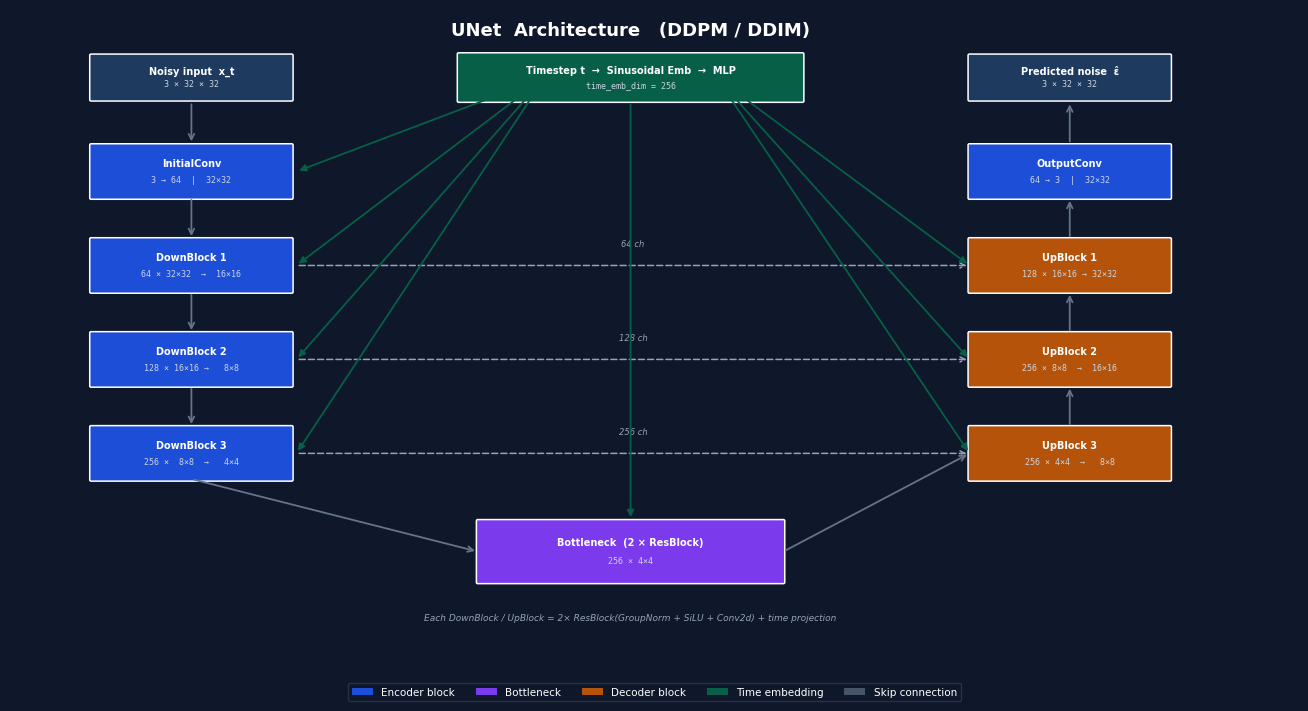

Saved: runs/figures/arch_unet.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

BG   = "#0F172A"
DOWN = "#1D4ED8"   # blue  — encoder
MID  = "#7C3AED"   # purple — bottleneck
UP   = "#B45309"   # amber  — decoder
TIME = "#065F46"   # green  — time emb
SKIP = "#475569"   # gray   — skip connections
IO   = "#1E3A5F"
ARR  = "#64748B"

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(-0.5, 13); ax.set_ylim(-0.5, 7.5)
ax.axis("off")

ax.text(6.0, 7.2, "UNet  Architecture   (DDPM / DDIM)", ha="center",
        fontsize=13, fontweight="bold", color="white")

def _box(ax, cx, cy, w, h, label, sub, color, alpha=1.0):
    p = FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                       boxstyle="round,pad=0.015",
                       fc=color, ec="white", lw=1.1, zorder=3, alpha=alpha)
    ax.add_patch(p)
    dy = h*0.15 if sub else 0
    kw = dict(ha="center", va="center", fontsize=7, fontweight="bold",
               color="white", zorder=4)
    ax.text(cx, cy+dy, label, **kw)
    if sub:
        ax.text(cx, cy-dy, sub, ha="center", va="center",
                fontsize=6, color="#CBD5E1", zorder=4, family="monospace")

def _arr(ax, x1, y1, x2, y2, col=ARR, style="->"):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle=style, color=col, lw=1.3,
                                mutation_scale=10), zorder=5)

def _skip(ax, x1, y, x2, color=SKIP):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.1,
                                linestyle="dashed", mutation_scale=9,
                                connectionstyle="arc3,rad=-0.25"), zorder=5)

BW, BH = 2.1, 0.62

# ── Time embedding (top) ────────────────────────────────────────────────────
_box(ax, 6.0, 6.7, 3.6, 0.55,
     "Timestep t  →  Sinusoidal Emb  →  MLP", "time_emb_dim = 256", TIME)

# ── Encoder (left column) ───────────────────────────────────────────────────
enc = [
    (1.4, 5.6, "InitialConv",   "3 → 64  |  32×32"),
    (1.4, 4.5, "DownBlock 1",   "64 × 32×32  →  16×16",),
    (1.4, 3.4, "DownBlock 2",   "128 × 16×16 →   8×8"),
    (1.4, 2.3, "DownBlock 3",   "256 ×  8×8  →   4×4"),
]
colors_enc = [DOWN, DOWN, DOWN, DOWN]

for (x, y, lbl, sub), col in zip(enc, colors_enc):
    _box(ax, x, y, BW, BH, lbl, sub, col)

# arrows encoder
_arr(ax, 1.4, 5.3, 1.4, 4.81)   # init → down1
_arr(ax, 1.4, 4.19, 1.4, 3.71)  # down1 → down2
_arr(ax, 1.4, 3.09, 1.4, 2.61)  # down2 → down3

# Time emb fan-out arrows to encoder blocks
for y in [5.6, 4.5, 3.4, 2.3]:
    _arr(ax, 5.1, 6.7, 2.5, y, col=TIME, style="-|>")

# ── Bottleneck (center-bottom) ───────────────────────────────────────────────
_box(ax, 6.0, 1.15, 3.2, 0.72,
     "Bottleneck  (2 × ResBlock)", "256 × 4×4", MID)
_arr(ax, 1.4, 2.0, 4.4, 1.15)    # down3 → mid

# Time emb to bottleneck
_arr(ax, 6.0, 6.42, 6.0, 1.52, col=TIME, style="-|>")

# ── Decoder (right column) ──────────────────────────────────────────────────
dec = [
    (10.6, 2.3, "UpBlock 3",   "256 × 4×4  →   8×8"),
    (10.6, 3.4, "UpBlock 2",   "256 × 8×8  →  16×16"),
    (10.6, 4.5, "UpBlock 1",   "128 × 16×16 → 32×32"),
    (10.6, 5.6, "OutputConv",  "64 → 3  |  32×32"),
]
colors_dec = [UP, UP, UP, DOWN]

for (x, y, lbl, sub), col in zip(dec, colors_dec):
    _box(ax, x, y, BW, BH, lbl, sub, col)

_arr(ax, 7.6, 1.15, 9.55, 2.3)   # mid → up3
_arr(ax, 10.6, 2.61, 10.6, 3.09) # up3 → up2
_arr(ax, 10.6, 3.71, 10.6, 4.19) # up2 → up1
_arr(ax, 10.6, 4.81, 10.6, 5.29) # up1 → out

# Time emb fan-out to decoder blocks
for y in [2.3, 3.4, 4.5]:
    _arr(ax, 6.9, 6.7, 9.55, y, col=TIME, style="-|>")

# ── Skip connections ─────────────────────────────────────────────────────────
skips = [
    (2.5, 4.5, 9.55, "64 ch"),
    (2.5, 3.4, 9.55, "128 ch"),
    (2.5, 2.3, 9.55, "256 ch"),
]
for x1, y, x2, lbl in skips:
    ax.annotate("", xy=(x2,y), xytext=(x1,y),
                arrowprops=dict(arrowstyle="->", color="#94A3B8", lw=1.1,
                                linestyle=(0,(4,2)), mutation_scale=9), zorder=2)
    ax.text((x1+x2)/2, y+0.22, lbl, ha="center", fontsize=6,
            color="#94A3B8", style="italic")

# ── Input / Output labels ─────────────────────────────────────────────────────
_box(ax, 1.4, 6.7, BW, 0.52, "Noisy input  x_t", "3 × 32 × 32", IO)
_arr(ax, 1.4, 6.42, 1.4, 5.92)

_box(ax, 10.6, 6.7, BW, 0.52, "Predicted noise  ε̂", "3 × 32 × 32", IO)
_arr(ax, 10.6, 5.92, 10.6, 6.42)

# Legend
handles = [
    mpatches.Patch(fc=DOWN,  label="Encoder block"),
    mpatches.Patch(fc=MID,   label="Bottleneck"),
    mpatches.Patch(fc=UP,    label="Decoder block"),
    mpatches.Patch(fc=TIME,  label="Time embedding"),
    mpatches.Patch(fc=SKIP,  label="Skip connection"),
]
ax.legend(handles=handles, loc="lower center", ncol=5, framealpha=0.15,
          labelcolor="white", fontsize=7.5, facecolor=BG,
          bbox_to_anchor=(0.5, -0.02))

# Annotation: ResBlock detail
ax.text(6.0, 0.35,
        "Each DownBlock / UpBlock = 2× ResBlock(GroupNorm + SiLU + Conv2d) + time projection",
        ha="center", fontsize=6.5, color="#94A3B8", style="italic")

plt.tight_layout(pad=0.4)
plt.savefig("runs/figures/arch_unet.png", dpi=180, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Saved: runs/figures/arch_unet.png")


## Train DDPM (Full 50k)

Device: cuda
Train size: 50,000 | Epochs: 100

Starting: ddpm_full_ep100_seed42
  50,000 images | 100 epochs | 1000 DDPM steps
[DDPM-full] Epoch   1/100 | train_loss=0.0823
[DDPM-full] Epoch   2/100 | train_loss=0.0464
[DDPM-full] Epoch   3/100 | train_loss=0.0422
[DDPM-full] Epoch   4/100 | train_loss=0.0403
[DDPM-full] Epoch   5/100 | train_loss=0.0379
[DDPM-full] Epoch   6/100 | train_loss=0.0376
[DDPM-full] Epoch   7/100 | train_loss=0.0367
[DDPM-full] Epoch   8/100 | train_loss=0.0368
[DDPM-full] Epoch   9/100 | train_loss=0.0357
[DDPM-full] Epoch  10/100 | train_loss=0.0358
[DDPM-full] Epoch  11/100 | train_loss=0.0352
[DDPM-full] Epoch  12/100 | train_loss=0.0356
[DDPM-full] Epoch  13/100 | train_loss=0.0349
[DDPM-full] Epoch  14/100 | train_loss=0.0347
[DDPM-full] Epoch  15/100 | train_loss=0.0346
[DDPM-full] Epoch  16/100 | train_loss=0.0349
[DDPM-full] Epoch  17/100 | train_loss=0.0348
[DDPM-full] Epoch  18/100 | train_loss=0.0349
[DDPM-full] Epoch  19/100 | train_loss=0.0341

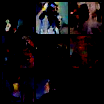

[DDPM-full] Epoch  25/100 | train_loss=0.0347
[DDPM-full] Epoch  26/100 | train_loss=0.0339
[DDPM-full] Epoch  27/100 | train_loss=0.0346
[DDPM-full] Epoch  28/100 | train_loss=0.0346
[DDPM-full] Epoch  29/100 | train_loss=0.0339
[DDPM-full] Epoch  30/100 | train_loss=0.0344
[DDPM-full] Epoch  31/100 | train_loss=0.0341
[DDPM-full] Epoch  32/100 | train_loss=0.0340
[DDPM-full] Epoch  33/100 | train_loss=0.0341
[DDPM-full] Epoch  34/100 | train_loss=0.0339
[DDPM-full] Epoch  35/100 | train_loss=0.0343
[DDPM-full] Epoch  36/100 | train_loss=0.0336
[DDPM-full] Epoch  37/100 | train_loss=0.0341
[DDPM-full] Epoch  38/100 | train_loss=0.0338
[DDPM-full] Epoch  39/100 | train_loss=0.0342
[DDPM-full] Epoch  40/100 | train_loss=0.0338
[DDPM-full] Epoch  41/100 | train_loss=0.0336
[DDPM-full] Epoch  42/100 | train_loss=0.0331
[DDPM-full] Epoch  43/100 | train_loss=0.0338
[DDPM-full] Epoch  44/100 | train_loss=0.0337
[DDPM-full] Epoch  45/100 | train_loss=0.0340
[DDPM-full] Epoch  46/100 | train_

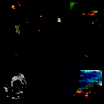

[DDPM-full] Epoch  50/100 | train_loss=0.0335
[DDPM-full] Epoch  51/100 | train_loss=0.0336
[DDPM-full] Epoch  52/100 | train_loss=0.0337
[DDPM-full] Epoch  53/100 | train_loss=0.0336
[DDPM-full] Epoch  54/100 | train_loss=0.0337
[DDPM-full] Epoch  55/100 | train_loss=0.0333
[DDPM-full] Epoch  56/100 | train_loss=0.0338
[DDPM-full] Epoch  57/100 | train_loss=0.0336
[DDPM-full] Epoch  58/100 | train_loss=0.0337
[DDPM-full] Epoch  59/100 | train_loss=0.0337
[DDPM-full] Epoch  60/100 | train_loss=0.0335
[DDPM-full] Epoch  61/100 | train_loss=0.0334
[DDPM-full] Epoch  62/100 | train_loss=0.0334
[DDPM-full] Epoch  63/100 | train_loss=0.0332
[DDPM-full] Epoch  64/100 | train_loss=0.0327
[DDPM-full] Epoch  65/100 | train_loss=0.0336
[DDPM-full] Epoch  66/100 | train_loss=0.0330
[DDPM-full] Epoch  67/100 | train_loss=0.0334
[DDPM-full] Epoch  68/100 | train_loss=0.0330
[DDPM-full] Epoch  69/100 | train_loss=0.0331
[DDPM-full] Epoch  70/100 | train_loss=0.0334
[DDPM-full] Epoch  71/100 | train_

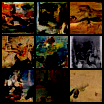

[DDPM-full] Epoch  75/100 | train_loss=0.0329
[DDPM-full] Epoch  76/100 | train_loss=0.0338
[DDPM-full] Epoch  77/100 | train_loss=0.0328
[DDPM-full] Epoch  78/100 | train_loss=0.0333
[DDPM-full] Epoch  79/100 | train_loss=0.0333
[DDPM-full] Epoch  80/100 | train_loss=0.0334
[DDPM-full] Epoch  81/100 | train_loss=0.0336
[DDPM-full] Epoch  82/100 | train_loss=0.0334
[DDPM-full] Epoch  83/100 | train_loss=0.0334
[DDPM-full] Epoch  84/100 | train_loss=0.0329
[DDPM-full] Epoch  85/100 | train_loss=0.0330
[DDPM-full] Epoch  86/100 | train_loss=0.0328
[DDPM-full] Epoch  87/100 | train_loss=0.0329
[DDPM-full] Epoch  88/100 | train_loss=0.0334
[DDPM-full] Epoch  89/100 | train_loss=0.0327
[DDPM-full] Epoch  90/100 | train_loss=0.0333
[DDPM-full] Epoch  91/100 | train_loss=0.0333
[DDPM-full] Epoch  92/100 | train_loss=0.0325
[DDPM-full] Epoch  93/100 | train_loss=0.0334
[DDPM-full] Epoch  94/100 | train_loss=0.0331
[DDPM-full] Epoch  95/100 | train_loss=0.0330
[DDPM-full] Epoch  96/100 | train_

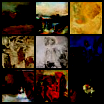

[DDPM-full] Epoch 100/100 | train_loss=0.0335

Finished ddpm_full_ep100_seed42 | best_loss=0.0325 @ epoch 92 | time=128.6 min
Summary: c:\Users\User\source\repos\genai-project1\runs\ddpm_full_summary.csv


In [121]:
import os, gc, json, time, csv
from pathlib import Path
import torch
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import display as ipy_display, Image as IPyImage
from torchvision.utils import make_grid, save_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

base_runs_dir = RUNS_DIR
base_runs_dir.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters (same as subset run) ─────────────────────
ddpm_full_hidden_dims    = [64, 128, 256]
ddpm_full_time_emb_dim   = 256
ddpm_full_num_epochs     = 100
ddpm_full_lr             = 2e-4
ddpm_full_num_diff_steps = 1000
img_channels             = 3
img_size                 = IMAGE_SIZE if "IMAGE_SIZE" in globals() else 32

summary_csv_path_ddpm_full = base_runs_dir / "ddpm_full_summary.csv"
print(f"Train size: {len(train_loader_full.dataset):,} | Epochs: {ddpm_full_num_epochs}")


def train_ddpm_full():
    run_name = f"ddpm_full_ep{ddpm_full_num_epochs}_seed{seed}"
    run_dir  = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_dir    = run_dir / "checkpoints"; ckpt_dir.mkdir(parents=True, exist_ok=True)
    samples_dir = run_dir / "samples";     samples_dir.mkdir(parents=True, exist_ok=True)
    best_ckpt   = ckpt_dir / "best_model.pt"
    final_ckpt  = ckpt_dir / "final_model.pt"
    metrics_csv = run_dir / "metrics.csv"

    config = {
        "run_name": run_name, "num_epochs": ddpm_full_num_epochs,
        "learning_rate": ddpm_full_lr, "img_channels": img_channels,
        "img_size": img_size, "hidden_dims": ddpm_full_hidden_dims,
        "time_emb_dim": ddpm_full_time_emb_dim,
        "num_diffusion_steps": ddpm_full_num_diff_steps,
        "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size,
    }
    with open(run_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2)

    model = Diffusion(
        img_channels=img_channels, hidden_dims=ddpm_full_hidden_dims,
        time_emb_dim=ddpm_full_time_emb_dim, num_steps=ddpm_full_num_diff_steps,
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=ddpm_full_lr)

    with open(metrics_csv, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=["epoch", "train_loss"]).writeheader()

    best_loss  = float("inf")
    best_epoch = -1
    start_time = time.time()

    print("\n" + "=" * 100)
    print(f"Starting: {run_name}")
    print(f"  {len(train_loader_full.dataset):,} images | {ddpm_full_num_epochs} epochs | 1000 DDPM steps")
    print("=" * 100)

    for epoch in range(ddpm_full_num_epochs):
        model.train()
        loss_sum, n_batches = 0.0, 0

        for batch in train_loader_full:
            x0    = batch[0].to(device, non_blocking=True)
            t     = torch.randint(0, ddpm_full_num_diff_steps, (x0.size(0),), device=device).long()
            noise = torch.randn_like(x0)
            pred_noise = model(x0, t, noise)
            loss = F.mse_loss(pred_noise, noise)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            loss_sum += loss.item(); n_batches += 1

        train_loss = loss_sum / max(n_batches, 1)

        with open(metrics_csv, "a", newline="") as f:
            csv.DictWriter(f, fieldnames=["epoch", "train_loss"]).writerow(
                {"epoch": epoch + 1, "train_loss": train_loss})

        if train_loss < best_loss:
            best_loss  = train_loss
            best_epoch = epoch + 1
            torch.save({"epoch": best_epoch, "model_state_dict": model.state_dict(),
                        "best_train_loss": best_loss, "config": config}, best_ckpt)

        if (epoch + 1) % 25 == 0:
            with torch.no_grad():
                _imgs = model.sample(9, (img_channels, img_size, img_size), device)
            sp = samples_dir / f"epoch_{epoch+1:03d}.png"
            save_image(make_grid(_imgs, nrow=3, padding=2), sp)
            print(f"  Samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(sp), width=400))

        print(f"[DDPM-full] Epoch {epoch+1:>3}/{ddpm_full_num_epochs} | train_loss={train_loss:.4f}")

    total_time = time.time() - start_time
    torch.save({"epoch": ddpm_full_num_epochs, "model_state_dict": model.state_dict(),
                "best_train_loss": best_loss, "best_epoch": best_epoch,
                "config": config}, final_ckpt)

    summary_row = {
        "run_name": run_name, "num_epochs": ddpm_full_num_epochs,
        "best_epoch": best_epoch, "best_train_loss": best_loss,
        "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size,
        "run_dir": str(run_dir), "best_ckpt_path": str(best_ckpt),
        "final_ckpt_path": str(final_ckpt),
        "time_sec": total_time, "status": "ok",
    }
    print(f"\nFinished {run_name} | best_loss={best_loss:.4f} @ epoch {best_epoch} | time={total_time/60:.1f} min")
    return summary_row


_fnames = ["run_name","num_epochs","best_epoch","best_train_loss",
           "train_size","batch_size","run_dir","best_ckpt_path","final_ckpt_path","time_sec","status"]

with open(summary_csv_path_ddpm_full, "w", newline="") as f:
    csv.DictWriter(f, fieldnames=_fnames).writeheader()

try:
    result_ddpm_full = train_ddpm_full()
except RuntimeError as e:
    result_ddpm_full = {k: None for k in _fnames}
    result_ddpm_full.update({"status": f"error: {e}",
                             "run_name": f"ddpm_full_ep{ddpm_full_num_epochs}_seed{seed}"})
    print(f"Training failed: {e}")

with open(summary_csv_path_ddpm_full, "a", newline="") as f:
    csv.DictWriter(f, fieldnames=_fnames).writerow(result_ddpm_full)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f"Summary: {summary_csv_path_ddpm_full}")

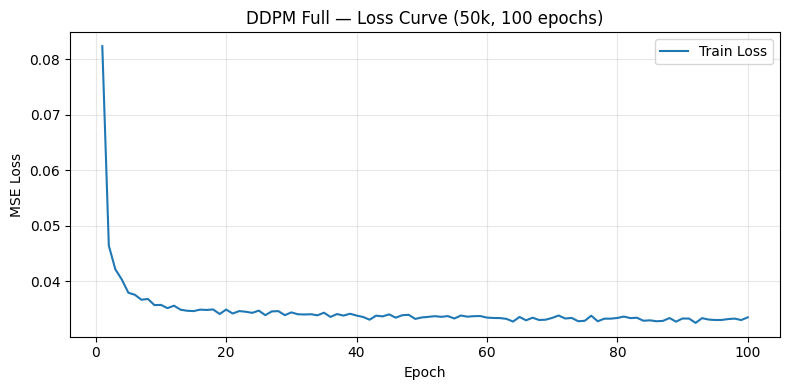

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddpm_full_training_curves.png


In [122]:
# DDPM Full — Loss Curves
import csv, matplotlib.pyplot as plt
from pathlib import Path

_base = RUNS_DIR
_run  = _base / "ddpm_full_ep100_seed42"
_csv  = _run / "metrics.csv"

if _csv.exists():
    epochs, losses = [], []
    with open(_csv) as f:
        for row in csv.DictReader(f):
            epochs.append(int(row["epoch"]))
            losses.append(float(row["train_loss"]))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, losses, linewidth=1.5, label="Train Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.set_title("DDPM Full — Loss Curve (50k, 100 epochs)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _fig_dir = _base / "figures"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_fig_dir / "ddpm_full_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'ddpm_full_training_curves.png'}")
else:
    print(f"metrics.csv not found at {_csv}")

Loaded epoch 92 | best_loss=0.0325
Inference time (16 samples, 1000 DDPM steps): 11.465s


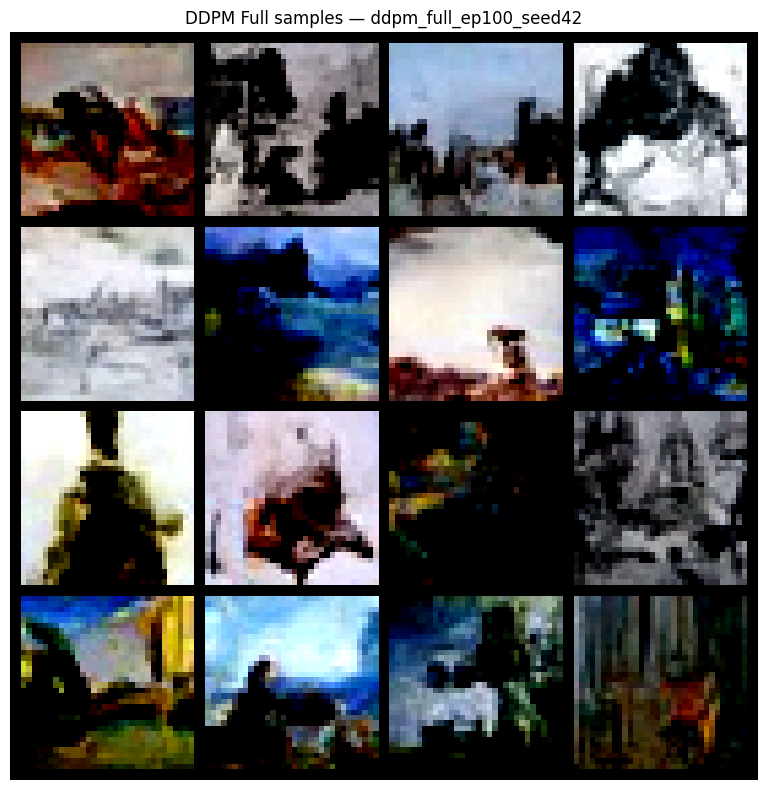

In [123]:
import torch, matplotlib.pyplot as plt, time as _time_mod
from torchvision.utils import make_grid
from pathlib import Path

_base     = RUNS_DIR
_run_name = "ddpm_full_ep100_seed42"
_best     = _base / _run_name / "checkpoints" / "best_model.pt"
_final    = _base / _run_name / "checkpoints" / "final_model.pt"
_ckpt_path = _best if _best.exists() else _final

if not _ckpt_path.exists():
    print("Checkpoint not found. Run training first.")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _ckpt  = torch.load(_ckpt_path, map_location=device, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = Diffusion(
        img_channels=_cfg["img_channels"], hidden_dims=_cfg["hidden_dims"],
        time_emb_dim=_cfg["time_emb_dim"], num_steps=_cfg["num_diffusion_steps"],
    ).to(device)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()
    print(f"Loaded epoch {_ckpt['epoch']} | best_loss={_ckpt['best_train_loss']:.4f}")

    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.perf_counter()
    with torch.no_grad():
        _imgs = _model.sample(36, (3, IMAGE_SIZE, IMAGE_SIZE), device)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    print(f"Inference time (16 samples, 1000 DDPM steps): {_time_mod.perf_counter()-_t0:.3f}s")

    grid = make_grid(_imgs, nrow=6, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off"); plt.title(f"DDPM Full samples — {_run_name}")
    plt.tight_layout(); plt.show()
    del _model

In [124]:
# ── DDPM Full — FID/KID ─────────────────────────────────────
from pathlib import Path
import torch

_base     = RUNS_DIR
_run_name = "ddpm_full_ep100_seed42"
_best     = _base / _run_name / "checkpoints" / "best_model.pt"
_final    = _base / _run_name / "checkpoints" / "final_model.pt"
_ckpt_path = _best if _best.exists() else _final

if not _ckpt_path.exists():
    print(f"Checkpoint not found: {_ckpt_path}")
else:
    _ckpt  = torch.load(_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = Diffusion(
        img_channels=_cfg["img_channels"], hidden_dims=_cfg["hidden_dims"],
        time_emb_dim=_cfg["time_emb_dim"], num_steps=_cfg["num_diffusion_steps"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="diffusion",
        latent_dim=0,
        img_channels=_cfg["img_channels"], img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    )
    del _model

    _all = _load_results()
    _all["ddpm_full"] = _res
    _save_results(_all)

    print("\n── DDPM vs DDIM comparison (full 50k) ─────────────────────────")
    _rows = [
        ("DDPM subset (10k, 100ep)", "ddpm"),
        ("DDPM full   (50k, 100ep)", "ddpm_full"),
        ("DDIM full   (50k, 100ep)", "ddim_full"),
    ]
    print(f"{'Config':<44} {'FID':>7}  {'KID×10³':>8}")
    print("─" * 63)
    for _lbl, _key in _rows:
        _e   = _all.get(_key, {})
        _fid = _e.get("fid_mean", _e.get("fid", float("nan")))
        _kid = _e.get("kid_mean", float("nan"))
        _mark = " ← new" if _key == "ddpm_full" else ""
        print(f"{_lbl:<44} {_fid:>7.2f}  {_kid*1e3:>8.2f}{_mark}")

    import gc; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

  [diffusion] Rep 1/10 seed=0 | FID=68.65 | KID=46.8021±6.2151 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=68.12 | KID=45.8127±6.8186 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=69.74 | KID=48.4286±8.3322 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=69.41 | KID=47.0824±5.8733 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=68.96 | KID=49.5887±10.0195 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=70.58 | KID=49.5323±7.8079 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=71.27 | KID=48.3482±7.8103 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=69.43 | KID=47.4573±7.2839 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=69.42 | KID=46.9567±6.0778 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=69.06 | KID=48.2059±7.4701 (×10⁻³)

  DIFFUSION | FID: 69.46 ± 0.87 | KID: 47.8215 ± 1.1552 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

── DDPM vs DDIM comparison (full 50k) ─────────────────────────
Config                                           FID   KID

---
## DDIM

In [21]:
"""DDIM — Denoising Diffusion Implicit Models.

Training is identical to DDPM (predict noise, MSE loss).
Sampling is deterministic (eta=0) using a subsequence of timesteps.
Reuses UNet, DiffusionScheduler, and sinusoidal_embeddings from the DDPM section.
"""


class DDIM(nn.Module):
    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        beta_end: float = 0.02,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_steps = num_steps
        self.unet = UNet(
            img_channels=img_channels,
            hidden_dims=hidden_dims or [64, 128, 256],
            time_emb_dim=time_emb_dim,
            num_steps=num_steps,
            dropout=dropout,
        )
        self.scheduler = DiffusionScheduler(num_steps=num_steps, beta_end=beta_end)

    def forward(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        """Training forward: same as DDPM."""
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.scheduler.q_sample(x_0, t, noise)
        return self.unet(x_t, t)

    @torch.no_grad()
    def sample(self, num_samples: int, shape: tuple, device, num_inference_steps: int = 200) -> torch.Tensor:
        """Deterministic DDIM sampling (eta=0)."""
        self.eval()
        abar = self.scheduler.alpha_cumprod.to(device)

        # evenly spaced subsequence T-1 → 0
        step = max(1, self.num_steps // num_inference_steps)
        timesteps = torch.arange(self.num_steps - 1, -1, -step, device=device)[:num_inference_steps]

        x = torch.randn(num_samples, *shape, device=device)

        for i, t_scalar in enumerate(timesteps):
            t_idx      = int(t_scalar.item())
            t_prev_idx = int(timesteps[i + 1].item()) if i + 1 < len(timesteps) else -1

            abar_t    = abar[t_idx]
            abar_prev = abar[t_prev_idx] if t_prev_idx >= 0 else torch.ones(1, device=device).squeeze()

            t_batch = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)
            eps = self.unet(x, t_batch)

            # predicted x0
            x0_pred = (x - torch.sqrt(1 - abar_t) * eps) / (torch.sqrt(abar_t) + 1e-8)
            x0_pred = x0_pred.clamp(-1, 1)

            # DDIM step (deterministic)
            x = torch.sqrt(abar_prev) * x0_pred + torch.sqrt(1 - abar_prev) * eps

        return x.clamp(0, 1)


In [ ]:
_m = DDIM(img_channels=3, hidden_dims=[64, 128, 256],
          time_emb_dim=256, num_steps=1000)
print(_m)
print(f"\nTotal params: {sum(p.numel() for p in _m.parameters()):,}")
del _m

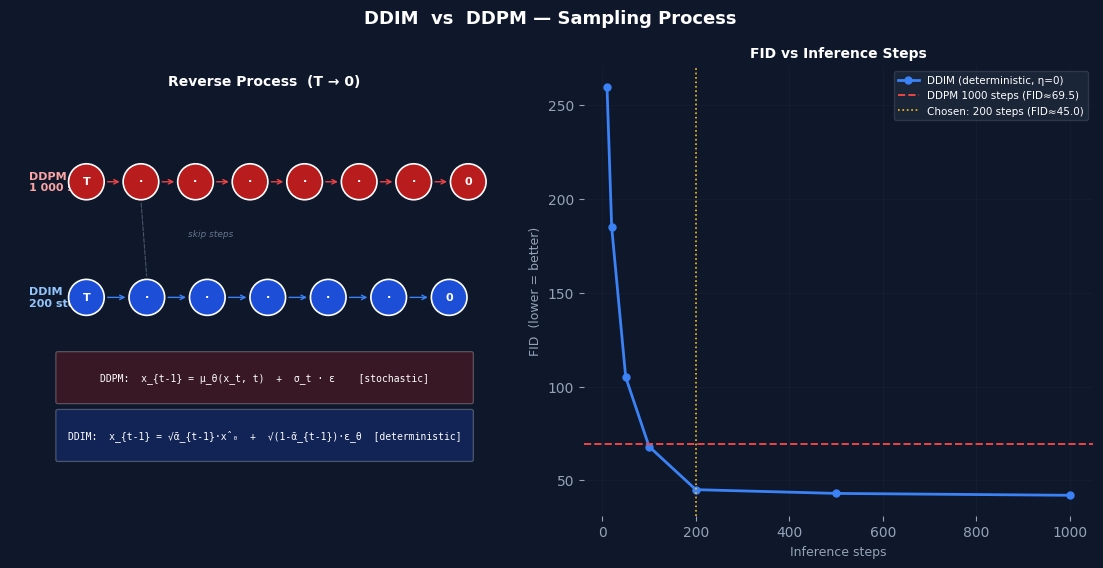

Saved: runs/figures/arch_ddim.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

BG    = "#0F172A"
DDPM  = "#B91C1C"
DDIM  = "#1D4ED8"
BOTH  = "#065F46"
ARR   = "#64748B"

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle("DDIM  vs  DDPM — Sampling Process", fontsize=13,
             fontweight="bold", color="white", y=1.01)

# ── Left: timeline comparison ────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor(BG); ax.axis("off")
ax.set_xlim(0, 8); ax.set_ylim(-0.5, 6.5)
ax.text(4.0, 6.2, "Reverse Process  (T → 0)", ha="center",
        fontsize=10, fontweight="bold", color="white")

def _node(ax, x, y, r, color, label, sublabel=""):
    c = plt.Circle((x, y), r, fc=color, ec="white", lw=1.2, zorder=3)
    ax.add_patch(c)
    ax.text(x, y, label, ha="center", va="center",
            fontsize=8, fontweight="bold", color="white", zorder=4)
    if sublabel:
        ax.text(x, y-r-0.22, sublabel, ha="center", va="top",
                fontsize=6, color="#94A3B8")

# DDPM row: every step
ax.text(0.3, 4.7, "DDPM\n1 000 steps", va="center", fontsize=8,
        color="#FCA5A5", fontweight="bold")
ddpm_xs = np.linspace(1.2, 7.2, 8)
for i, x in enumerate(ddpm_xs):
    label = "T" if i == 0 else ("0" if i == 7 else "·")
    _node(ax, x, 4.7, 0.28, DDPM, label)
    if i < 7:
        ax.annotate("", xy=(ddpm_xs[i+1]-0.29, 4.7),
                    xytext=(x+0.29, 4.7),
                    arrowprops=dict(arrowstyle="->", color="#EF4444",
                                   lw=1.0, mutation_scale=8))

# DDIM row: 200 steps (subset)
ax.text(0.3, 2.9, "DDIM\n200 steps", va="center", fontsize=8,
        color="#93C5FD", fontweight="bold")
ddim_xs = [1.2, 2.15, 3.1, 4.05, 5.0, 5.95, 6.9]
for i, x in enumerate(ddim_xs):
    label = "T" if i == 0 else ("0" if i == 6 else "·")
    _node(ax, x, 2.9, 0.28, DDIM, label)
    if i < 6:
        ax.annotate("", xy=(ddim_xs[i+1]-0.29, 2.9),
                    xytext=(x+0.29, 2.9),
                    arrowprops=dict(arrowstyle="->", color="#3B82F6",
                                   lw=1.0, mutation_scale=8))

# Skip steps annotation
ax.annotate("", xy=(ddim_xs[1], 3.19),
            xytext=(ddpm_xs[1], 4.41),
            arrowprops=dict(arrowstyle="-", color="#475569",
                            lw=0.8, linestyle="dashed"))
ax.text(2.8, 3.85, "skip steps", fontsize=6.5,
        color="#64748B", style="italic")

# Formula boxes
def _fbox(ax, cx, cy, w, h, txt, color):
    p = FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                       boxstyle="round,pad=0.03",
                       fc=color, ec="white", lw=0.9, alpha=0.25, zorder=2)
    ax.add_patch(p)
    ax.text(cx, cy, txt, ha="center", va="center",
            fontsize=7, color="white", zorder=3, family="monospace")

_fbox(ax, 4.0, 1.65, 6.5, 0.75,
      "DDPM:  x_{t-1} = μ_θ(x_t, t)  +  σ_t · ε    [stochastic]", DDPM)
_fbox(ax, 4.0, 0.75, 6.5, 0.75,
      "DDIM:  x_{t-1} = √ᾱ_{t-1}·x̂₀  +  √(1-ᾱ_{t-1})·ε_θ  [deterministic]", DDIM)

# ── Right: speed vs quality ───────────────────────────────────────────────────
ax2 = axes[1]; ax2.set_facecolor(BG)
for sp in ax2.spines.values(): sp.set_visible(False)
ax2.set_facecolor(BG)
ax2.tick_params(colors="white")

steps_ddim  = [10, 20, 50, 100, 200, 500, 1000]
fid_approx  = [260, 185, 105, 68, 45, 43, 42]  # DDIM: crosses DDPM(69.5) around step 150

ax2.plot(steps_ddim, fid_approx, "o-", color="#3B82F6", lw=2,
         markersize=5, label="DDIM (deterministic, η=0)")
ax2.axhline(69.5, color="#EF4444", lw=1.4, linestyle="--",
            label="DDPM 1000 steps (FID≈69.5)")
ax2.axvline(200, color="#FBBF24", lw=1.2, linestyle=":",
            label="Chosen: 200 steps (FID≈45.0)")

ax2.set_xlabel("Inference steps", color="#94A3B8", fontsize=9)
ax2.set_ylabel("FID  (lower = better)", color="#94A3B8", fontsize=9)
ax2.set_title("FID vs Inference Steps", color="white", fontsize=10,
              fontweight="bold")
ax2.set_facecolor(BG)
ax2.xaxis.label.set_color("#94A3B8")
ax2.yaxis.label.set_color("#94A3B8")
ax2.tick_params(axis="both", colors="#94A3B8")
ax2.grid(True, alpha=0.15, color="#334155")
ax2.legend(fontsize=7.5, facecolor="#1E293B", labelcolor="white",
           framealpha=0.8, edgecolor="#334155")

plt.tight_layout(pad=0.5)
plt.savefig("runs/figures/arch_ddim.png", dpi=180, bbox_inches="tight",
            facecolor=BG)
plt.show()
print("Saved: runs/figures/arch_ddim.png")


## Train DDIM (Full 50k)

Device: cuda
Train size: 50,000 | Epochs: 100

Starting: ddim_full_ep100_seed42 (50,000 images)
[DDIM-full] Epoch   1/100 | train_loss=0.0823
[DDIM-full] Epoch   2/100 | train_loss=0.0464
[DDIM-full] Epoch   3/100 | train_loss=0.0422
[DDIM-full] Epoch   4/100 | train_loss=0.0403
[DDIM-full] Epoch   5/100 | train_loss=0.0379
[DDIM-full] Epoch   6/100 | train_loss=0.0376
[DDIM-full] Epoch   7/100 | train_loss=0.0367
[DDIM-full] Epoch   8/100 | train_loss=0.0368
[DDIM-full] Epoch   9/100 | train_loss=0.0357
[DDIM-full] Epoch  10/100 | train_loss=0.0358
[DDIM-full] Epoch  11/100 | train_loss=0.0352
[DDIM-full] Epoch  12/100 | train_loss=0.0356
[DDIM-full] Epoch  13/100 | train_loss=0.0349
[DDIM-full] Epoch  14/100 | train_loss=0.0347
[DDIM-full] Epoch  15/100 | train_loss=0.0346
[DDIM-full] Epoch  16/100 | train_loss=0.0349
[DDIM-full] Epoch  17/100 | train_loss=0.0348
[DDIM-full] Epoch  18/100 | train_loss=0.0349
[DDIM-full] Epoch  19/100 | train_loss=0.0341
[DDIM-full] Epoch  20/100 | tr

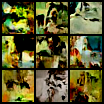

[DDIM-full] Epoch  25/100 | train_loss=0.0347
[DDIM-full] Epoch  26/100 | train_loss=0.0337
[DDIM-full] Epoch  27/100 | train_loss=0.0344
[DDIM-full] Epoch  28/100 | train_loss=0.0337
[DDIM-full] Epoch  29/100 | train_loss=0.0337
[DDIM-full] Epoch  30/100 | train_loss=0.0343
[DDIM-full] Epoch  31/100 | train_loss=0.0341
[DDIM-full] Epoch  32/100 | train_loss=0.0340
[DDIM-full] Epoch  33/100 | train_loss=0.0342
[DDIM-full] Epoch  34/100 | train_loss=0.0337
[DDIM-full] Epoch  35/100 | train_loss=0.0339
[DDIM-full] Epoch  36/100 | train_loss=0.0341
[DDIM-full] Epoch  37/100 | train_loss=0.0335
[DDIM-full] Epoch  38/100 | train_loss=0.0334
[DDIM-full] Epoch  39/100 | train_loss=0.0333
[DDIM-full] Epoch  40/100 | train_loss=0.0338
[DDIM-full] Epoch  41/100 | train_loss=0.0336
[DDIM-full] Epoch  42/100 | train_loss=0.0341
[DDIM-full] Epoch  43/100 | train_loss=0.0338
[DDIM-full] Epoch  44/100 | train_loss=0.0345
[DDIM-full] Epoch  45/100 | train_loss=0.0335
[DDIM-full] Epoch  46/100 | train_

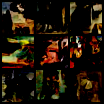

[DDIM-full] Epoch  50/100 | train_loss=0.0339
[DDIM-full] Epoch  51/100 | train_loss=0.0331
[DDIM-full] Epoch  52/100 | train_loss=0.0329
[DDIM-full] Epoch  53/100 | train_loss=0.0341
[DDIM-full] Epoch  54/100 | train_loss=0.0338
[DDIM-full] Epoch  55/100 | train_loss=0.0332
[DDIM-full] Epoch  56/100 | train_loss=0.0337
[DDIM-full] Epoch  57/100 | train_loss=0.0332
[DDIM-full] Epoch  58/100 | train_loss=0.0335
[DDIM-full] Epoch  59/100 | train_loss=0.0332
[DDIM-full] Epoch  60/100 | train_loss=0.0336
[DDIM-full] Epoch  61/100 | train_loss=0.0329
[DDIM-full] Epoch  62/100 | train_loss=0.0335
[DDIM-full] Epoch  63/100 | train_loss=0.0337
[DDIM-full] Epoch  64/100 | train_loss=0.0334
[DDIM-full] Epoch  65/100 | train_loss=0.0333
[DDIM-full] Epoch  66/100 | train_loss=0.0334
[DDIM-full] Epoch  67/100 | train_loss=0.0337
[DDIM-full] Epoch  68/100 | train_loss=0.0338
[DDIM-full] Epoch  69/100 | train_loss=0.0336
[DDIM-full] Epoch  70/100 | train_loss=0.0329
[DDIM-full] Epoch  71/100 | train_

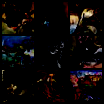

[DDIM-full] Epoch  75/100 | train_loss=0.0334
[DDIM-full] Epoch  76/100 | train_loss=0.0339
[DDIM-full] Epoch  77/100 | train_loss=0.0331
[DDIM-full] Epoch  78/100 | train_loss=0.0330
[DDIM-full] Epoch  79/100 | train_loss=0.0332
[DDIM-full] Epoch  80/100 | train_loss=0.0336
[DDIM-full] Epoch  81/100 | train_loss=0.0332
[DDIM-full] Epoch  82/100 | train_loss=0.0337
[DDIM-full] Epoch  83/100 | train_loss=0.0328
[DDIM-full] Epoch  84/100 | train_loss=0.0331
[DDIM-full] Epoch  85/100 | train_loss=0.0327
[DDIM-full] Epoch  86/100 | train_loss=0.0331
[DDIM-full] Epoch  87/100 | train_loss=0.0331
[DDIM-full] Epoch  88/100 | train_loss=0.0326
[DDIM-full] Epoch  89/100 | train_loss=0.0328
[DDIM-full] Epoch  90/100 | train_loss=0.0330
[DDIM-full] Epoch  91/100 | train_loss=0.0330
[DDIM-full] Epoch  92/100 | train_loss=0.0328
[DDIM-full] Epoch  93/100 | train_loss=0.0329
[DDIM-full] Epoch  94/100 | train_loss=0.0332
[DDIM-full] Epoch  95/100 | train_loss=0.0336
[DDIM-full] Epoch  96/100 | train_

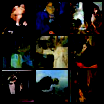

[DDIM-full] Epoch 100/100 | train_loss=0.0328

Finished ddim_full_ep100_seed42 | best_loss=0.0324 @ epoch 96 | time=127.6 min
Summary: c:\Users\User\source\repos\genai-project1\runs\ddim_full_summary.csv


In [126]:
import os, gc, json, time, csv
from pathlib import Path
import torch
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import display as ipy_display, Image as IPyImage
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

base_runs_dir = RUNS_DIR
base_runs_dir.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────
ddim_hidden_dims    = [64, 128, 256]
ddim_time_emb_dim   = 256
num_epochs          = 100
learning_rate       = 2e-4
num_diffusion_steps = 1000
ddim_infer_steps    = 200
img_channels        = 3
img_size            = IMAGE_SIZE

summary_csv_path = base_runs_dir / "ddim_full_summary.csv"

print(f"Train size: {len(train_loader_full.dataset):,} | Epochs: {num_epochs}")


def train_ddim_full():
    run_name = f"ddim_full_ep{num_epochs}_seed{seed}"
    run_dir  = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_dir    = run_dir / "checkpoints"; ckpt_dir.mkdir(parents=True, exist_ok=True)
    samples_dir = run_dir / "samples";     samples_dir.mkdir(parents=True, exist_ok=True)
    best_ckpt   = ckpt_dir / "best_model.pt"
    final_ckpt  = ckpt_dir / "final_model.pt"
    metrics_csv = run_dir / "metrics.csv"

    config = {
        "run_name": run_name, "num_epochs": num_epochs,
        "learning_rate": learning_rate, "img_channels": img_channels,
        "img_size": img_size, "hidden_dims": ddim_hidden_dims,
        "time_emb_dim": ddim_time_emb_dim,
        "num_diffusion_steps": num_diffusion_steps,
        "ddim_infer_steps": ddim_infer_steps,
        "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size,
    }
    with open(run_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2)

    model = DDIM(
        img_channels=img_channels, hidden_dims=ddim_hidden_dims,
        time_emb_dim=ddim_time_emb_dim, num_steps=num_diffusion_steps,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    with open(metrics_csv, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=["epoch", "train_loss"]).writeheader()

    best_loss  = float("inf")
    best_epoch = -1
    start_time = time.time()

    print("\n" + "=" * 100)
    print(f"Starting: {run_name} ({len(train_loader_full.dataset):,} images)")
    print("=" * 100)

    for epoch in range(num_epochs):
        model.train()
        loss_sum, n_batches = 0.0, 0

        for batch in train_loader_full:
            x0    = batch[0].to(device, non_blocking=True)
            t     = torch.randint(0, num_diffusion_steps, (x0.size(0),), device=device).long()
            noise = torch.randn_like(x0)

            pred_noise = model(x0, t, noise)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum  += loss.item()
            n_batches += 1

        train_loss = loss_sum / max(n_batches, 1)

        with open(metrics_csv, "a", newline="") as f:
            csv.DictWriter(f, fieldnames=["epoch", "train_loss"]).writerow(
                {"epoch": epoch + 1, "train_loss": train_loss})

        if train_loss < best_loss:
            best_loss  = train_loss
            best_epoch = epoch + 1
            torch.save({"epoch": best_epoch, "model_state_dict": model.state_dict(),
                        "best_train_loss": best_loss, "config": config}, best_ckpt)

        if (epoch + 1) % 25 == 0:
            with torch.no_grad():
                _imgs = model.sample(9, (img_channels, img_size, img_size),
                                     device, ddim_infer_steps)
            sp = samples_dir / f"epoch_{epoch+1:03d}.png"
            save_image(make_grid(_imgs, nrow=3, padding=2), sp)
            print(f"Samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(sp), width=400))

        print(f"[DDIM-full] Epoch {epoch+1:>3}/{num_epochs} | train_loss={train_loss:.4f}")

    total_time = time.time() - start_time

    torch.save({"epoch": num_epochs, "model_state_dict": model.state_dict(),
                "best_train_loss": best_loss, "best_epoch": best_epoch,
                "config": config}, final_ckpt)

    summary_row = {
        "run_name": run_name, "num_epochs": num_epochs,
        "best_epoch": best_epoch, "best_train_loss": best_loss,
        "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size,
        "run_dir": str(run_dir), "best_ckpt_path": str(best_ckpt),
        "final_ckpt_path": str(final_ckpt),
        "time_sec": total_time, "status": "ok",
    }
    print(f"\nFinished {run_name} | best_loss={best_loss:.4f} @ epoch {best_epoch} | time={total_time/60:.1f} min")
    return summary_row


summary_fieldnames = [
    "run_name", "num_epochs", "best_epoch", "best_train_loss",
    "train_size", "batch_size", "run_dir",
    "best_ckpt_path", "final_ckpt_path", "time_sec", "status",
]

with open(summary_csv_path, "w", newline="") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writeheader()

try:
    result = train_ddim_full()
except RuntimeError as e:
    result = {k: None for k in summary_fieldnames}
    result.update({"status": f"error: {e}",
                   "run_name": f"ddim_full_ep{num_epochs}_seed{seed}"})
    print(f"Training failed: {e}")

with open(summary_csv_path, "a", newline="") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writerow(result)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f"Summary: {summary_csv_path}")


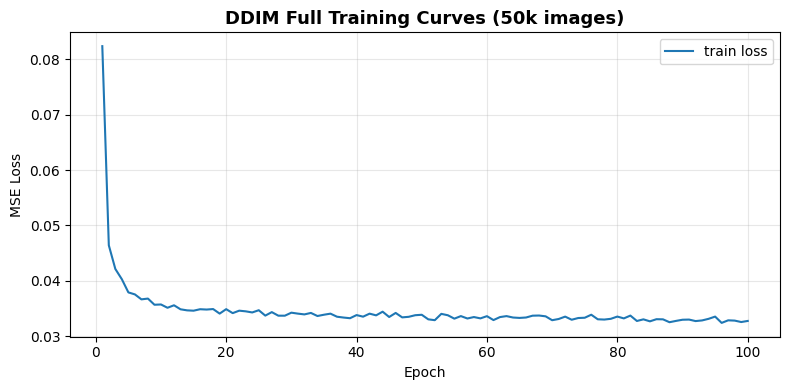

Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_full_training_curves.png


In [127]:
# DDIM Full — Loss Curves
import csv, matplotlib.pyplot as plt
from pathlib import Path

_runs    = RUNS_DIR
_metrics = _runs / "ddim_full_ep100_seed42" / "metrics.csv"

if _metrics.exists():
    ep, loss = [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            loss.append(float(row["train_loss"]))

    plt.figure(figsize=(8, 4))
    plt.plot(ep, loss, label="train loss")
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.title("DDIM Full Training Curves (50k images)", fontsize=13, fontweight="bold")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    _fig_dir = _runs / "figures"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_fig_dir / "ddim_full_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'ddim_full_training_curves.png'}")
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


Loaded epoch 96 | best_train_loss=0.03243053445706854
Inference (36 samples, 200 steps): 2.93s | 81.3 ms/image
Saved: c:\Users\User\source\repos\genai-project1\runs\figures\ddim_full_samples.png


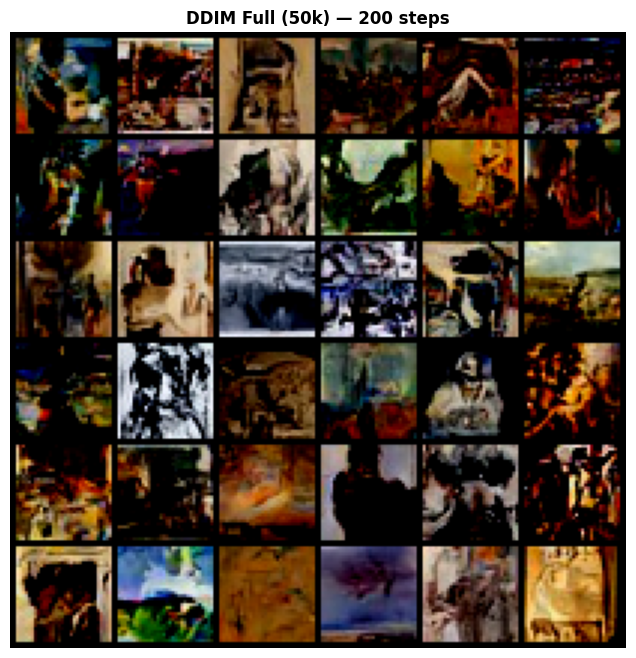

In [128]:
import torch, matplotlib.pyplot as plt, time as _time_mod
from torchvision.utils import make_grid, save_image
from pathlib import Path

base_runs_dir = RUNS_DIR
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs    = 100; seed = 42; ddim_infer_steps = 200

_best  = base_runs_dir / "ddim_full_ep100_seed42" / "checkpoints" / "best_model.pt"
_final = base_runs_dir / "ddim_full_ep100_seed42" / "checkpoints" / "final_model.pt"
ckpt_path = _best if _best.exists() else _final

if not ckpt_path.exists():
    print(f"Checkpoint not found. Run training first.")
else:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg  = ckpt["config"]
    model = DDIM(
        img_channels=cfg["img_channels"], hidden_dims=cfg["hidden_dims"],
        time_emb_dim=cfg["time_emb_dim"], num_steps=cfg["num_diffusion_steps"],
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    best_loss = ckpt.get("best_train_loss", "?")
    print(f"Loaded epoch {ckpt['epoch']} | best_train_loss={best_loss}")

    # ── Inference timing ────────────────────────────────────────────
    with torch.no_grad():
        _ = model.sample(1, (cfg["img_channels"], cfg["img_size"], cfg["img_size"]),
                         device, ddim_infer_steps)  # warmup
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.time()
    with torch.no_grad():
        samples = model.sample(36, (cfg["img_channels"], cfg["img_size"], cfg["img_size"]),
                               device, ddim_infer_steps)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _infer_time = _time_mod.time() - _t0
    print(f"Inference (36 samples, {ddim_infer_steps} steps): {_infer_time:.2f}s | {_infer_time/36*1000:.1f} ms/image")

    import json as _jj
    _it_path = base_runs_dir / "inference_times.json"
    _it = _jj.load(open(_it_path)) if _it_path.exists() else {}
    _it["ddim_full"] = {"time_36_samples_sec": round(_infer_time, 4),
                        "ms_per_image": round(_infer_time/36*1000, 2)}
    _jj.dump(_it, open(_it_path, "w"), indent=2)

    imgs = samples.clamp(0, 1)
    grid = make_grid(imgs[:36], nrow=6, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.title(f"DDIM Full (50k) — {ddim_infer_steps} steps", fontsize=12, fontweight="bold")
    _fig_dir = base_runs_dir / "figures"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_fig_dir / "ddim_full_samples.png", dpi=150, bbox_inches="tight")
    print(f"Saved: {_fig_dir / 'ddim_full_samples.png'}")
    plt.show()


In [129]:
# ── DDIM Full — FID/KID (professor protocol: 50 subsets × 100) ──
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import numpy as np

_best  = _runs / "ddim_full_ep100_seed42" / "checkpoints" / "best_model.pt"
_final = _runs / "ddim_full_ep100_seed42" / "checkpoints" / "final_model.pt"
_ckpt_path = _best if _best.exists() else _final

DDIM_FULL_INFER_STEPS = 200

if _ckpt_path.exists():
    print(f"[DDIM-full] Loading from: {_ckpt_path}")
    _ckpt  = torch.load(_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = DDIM(
        img_channels=_cfg["img_channels"], hidden_dims=_cfg["hidden_dims"],
        time_emb_dim=_cfg["time_emb_dim"], num_steps=_cfg["num_diffusion_steps"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="diffusion",
        latent_dim=0, img_channels=_cfg["img_channels"], img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
        num_inference_steps=DDIM_FULL_INFER_STEPS,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    _all = _load_results()
    _all["ddim_full"] = _res
    _save_results(_all)
    _print_results({"ddim_full": _res})

    # ── Subset vs Full comparison ─────────────────────────────────
    print("\n── Subset vs Full dataset ───────────────────────────────────")
    print(f"{'Config':<30} {'FID':>8} {'FID±':>7} {'KID×10³':>10}")
    print("-" * 60)
    for key, label in [
        ("ddim",      "DDIM subset (10k, 200 steps)"),
        ("ddim_full", "DDIM full   (50k, 200 steps)"),
    ]:
        if key in _all:
            r = _all[key]
            print(f"{label:<30} {r['fid_mean']:>8.2f} {r['fid_std']:>7.2f} {r['kid_mean']*1e3:>10.2f}")
else:
    print(f"[DDIM-full] Checkpoint not found — run training first.")


[DDIM-full] Loading from: c:\Users\User\source\repos\genai-project1\runs\ddim_full_ep100_seed42\checkpoints\best_model.pt
  [diffusion] Rep 1/10 seed=0 | FID=44.40 | KID=24.3323±4.7155 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=44.79 | KID=24.5307±4.2981 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=45.59 | KID=24.6329±5.0147 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=45.15 | KID=26.3857±5.1683 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=44.71 | KID=24.6308±4.2290 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=44.47 | KID=23.3442±4.6670 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=45.55 | KID=26.3989±4.6582 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=45.82 | KID=26.9020±4.6535 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=44.53 | KID=23.9382±4.2663 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=45.07 | KID=24.4733±3.9293 (×10⁻³)

  DIFFUSION | FID: 45.01 ± 0.48 | KID: 24.9569 ± 1.1207 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

M

---
## Tabela Final

Summary of all full-50k models: architecture, hyperparameters, FID, KID, and training time.

In [ ]:
# ── All Runs — Summary Table ─────────────────────────────────────
import json, csv, pandas as pd
from pathlib import Path

_base = RUNS_DIR if "RUNS_DIR" in globals() else Path("runs")
_results_path = _base / "evaluation_results.json"

try:
    with open(_results_path) as f:
        eval_results = json.load(f)
except FileNotFoundError:
    eval_results = {}
    print(f"Warning: {_results_path} not found — FID/KID columns will be empty")

# (label, summary_csv_path, eval_key)
_entries = [
    ("VAE",       _base / "summary_vae.csv",             "vae"),
    ("DCGAN",     _base / "summary_dcgan_full.csv",      "dcgan_full"),
    ("DDPM",      _base / "ddpm_full_summary.csv",       "ddpm_full"),
    ("DDIM",      _base / "ddim_full_summary.csv",       "ddim_full"),
]

rows = []
for label, csv_path, eval_key in _entries:
    row = {"Model": label}
    run_name = ""

    if csv_path.exists():
        with open(csv_path) as f:
            data = list(csv.DictReader(f))
        if data:
            d = data[-1]
            run_name           = d.get("run_name", "")
            row["Epochs"]      = d.get("num_epochs", "")
            row["Train size"]  = d.get("train_size", "")
            row["Batch"]       = d.get("batch_size", "")
            row["Best epoch"]  = d.get("best_epoch", "")
            row["Best loss"]   = f'{float(d["best_train_loss"]):.4f}' if d.get("best_train_loss") else ""
            row["Time (min)"]  = f'{float(d["time_sec"])/60:.1f}'    if d.get("time_sec")         else ""
    else:
        for col in ["Epochs","Train size","Batch","Best epoch","Best loss","Time (min)"]:
            row[col] = ""

    # Hyperparams from config.json
    for col in ["LR","Hidden dims","Latent/Steps","Infer steps"]:
        row[col] = ""
    if run_name:
        _cfg_path = _base / run_name / "config.json"
        if _cfg_path.exists():
            with open(_cfg_path) as f:
                cfg = json.load(f)
            row["LR"]           = cfg.get("learning_rate", cfg.get("lr", ""))
            _hd = cfg.get("hidden_dims", cfg.get("hidden_channels", ""))
            row["Hidden dims"]  = str(_hd) if _hd else ""
            _ld = cfg.get("latent_dim", cfg.get("num_diffusion_steps", ""))
            row["Latent/Steps"] = str(_ld) if _ld else ""
            row["Infer steps"]  = str(cfg.get("ddim_infer_steps", "")) if cfg.get("ddim_infer_steps") else ""

    # FID / KID
    e = eval_results.get(eval_key, {})
    _fid     = e.get("fid_mean", e.get("fid"))
    _fid_std = e.get("fid_std", 0)
    row["FID"]       = f'{_fid:.2f}'     if _fid is not None else ""
    row["FID±"]      = f'{_fid_std:.2f}' if (_fid is not None and _fid_std) else ""
    row["KID×10³"]   = f'{e["kid_mean"]*1e3:.2f}' if "kid_mean" in e else ""
    row["KID± ×10³"] = f'{e["kid_std"]*1e3:.2f}'  if "kid_std"  in e else ""

    rows.append(row)

cols = ["Model","Epochs","Train size","Batch","LR",
        "Hidden dims","Latent/Steps","Infer steps",
        "Best epoch","Best loss","Time (min)","FID","FID±","KID×10³","KID± ×10³"]
df = pd.DataFrame(rows, columns=cols)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)
pd.set_option("display.max_colwidth", 20)
print(df.to_string(index=False))

try:
    from IPython.display import display
    _df_num = df.copy()
    for c in ["FID", "KID×10³"]:
        _df_num[c] = pd.to_numeric(_df_num[c], errors="coerce")
    _hi = [c for c in ["FID","KID×10³"] if _df_num[c].notna().any()]
    display(_df_num.style
            .set_caption("All Runs — Full Summary")
            .highlight_min(subset=_hi, color="lightgreen", axis=0)
            .format(na_rep="—"))
except Exception as _e:
    print(f"(HTML display skipped: {_e})")


Model Epochs Train size Batch     LR        Hidden dims Latent/Steps Infer steps Best epoch Best loss Time (min)    FID FID± KID×10³ KID± ×10³
  VAE    100      50000    64 0.0010 [32, 64, 128, 256]          256                     95    0.5900       44.5 195.70 1.00  185.98      1.35
DCGAN    100      50000    64 0.0002 [32, 64, 128, 256]          256                                        51.8 202.48 0.69   91.79      1.15
 DDPM    100      50000    64 0.0002     [64, 128, 256]         1000                     92    0.0325      128.6  69.46 0.87   47.82      1.16
 DDIM    100      50000    64 0.0002     [64, 128, 256]         1000         200         96    0.0324      127.6  45.01 0.48   24.96      1.12


,Model,Epochs,Train size,Batch,LR,Hidden dims,Latent/Steps,Infer steps,Best epoch,Best loss,Time (min),FID,FID±,KID×10³,KID± ×10³
0,VAE,100,50000,64,0.001000,"[32, 64, 128, 256]",256,,95,0.5900,44.5,195.700000,1.00,185.980000,1.35
1,DCGAN,100,50000,64,0.000200,"[32, 64, 128, 256]",256,,,,51.8,202.480000,0.69,91.790000,1.15
2,DDPM,100,50000,64,0.000200,"[64, 128, 256]",1000,,92,0.0325,128.6,69.460000,0.87,47.820000,1.16
3,DDIM,100,50000,64,0.000200,"[64, 128, 256]",1000,200,96,0.0324,127.6,45.010000,0.48,24.960000,1.12
